In [2]:
!pip -q install -U datasets huggingface_hub pandas numpy pyarrow rasterio openpyxl

In [3]:
import os
import json
import numpy as np
import pandas as pd

from datasets import load_dataset
import sys
import subprocess

print("Python:", sys.version)

subprocess.check_call([
    sys.executable,
    "-m",
    "pip",
    "install",
    "--upgrade",
    "--force-reinstall",
    "numpy==2.2.6"
])

Python: 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]


0

In [4]:
import numpy as np

print("NumPy version:", np.__version__)
print("NumPy path:", np.__file__)

NumPy version: 2.2.6
NumPy path: /usr/local/lib/python3.13/dist-packages/numpy/__init__.py


In [5]:
import sys
import subprocess

subprocess.check_call([
    sys.executable,
    "-m",
    "pip",
    "install",
    "-U",
    "datasets",
    "huggingface_hub",
    "pyarrow",
    "pandas",
    "rasterio",
    "openpyxl"
])

0

In [7]:
import numpy as np
import datasets

print("NumPy:", np.__version__)
print("Datasets:", datasets.__version__)

NumPy: 2.2.6
Datasets: 5.0.1


In [8]:
from huggingface_hub import HfApi

api = HfApi()

info = api.dataset_info(
    "kostaspic/amfitrite-inland-waters-hab-sentinel2"
)

print("Dataset:", info.id)
print("Last modified:", info.lastModified)

Dataset: kostaspic/amfitrite-inland-waters-hab-sentinel2
Last modified: 2026-06-09 13:01:56+00:00


In [9]:
from datasets import load_dataset

DATASET_ID = "kostaspic/amfitrite-inland-waters-hab-sentinel2"

ds = load_dataset(
    DATASET_ID,
    split="train",
    streaming=True
)

print(ds)

Resolving data files:   0%|          | 0/89265 [00:00<?, ?it/s]

IterableDataset({
    features: ['image'],
    num_shards: 1
})


In [10]:
sample = next(iter(ds))

print("Sample received.")
print(sample.keys())

Sample received.
dict_keys(['image'])


In [11]:
for key, value in sample.items():
    print("\n" + "=" * 70)
    print("KEY:", key)
    print("TYPE:", type(value))

    if isinstance(value, dict):
        print("DICT KEYS:", value.keys())
    else:
        print("VALUE:", str(value)[:500])


KEY: image
TYPE: <class 'PIL.TiffImagePlugin.TiffImageFile'>
VALUE: <PIL.TiffImagePlugin.TiffImageFile image mode=I;16 size=365x365 at 0x7DC51D662CF0>


In [12]:
print("\nIMAGE OBJECT")
print("=" * 70)

image_obj = sample.get("image")

print("Type:", type(image_obj))

if isinstance(image_obj, dict):
    print("Keys:", image_obj.keys())

    for key, value in image_obj.items():
        print(
            f"{key}: "
            f"type={type(value)}, "
            f"value={str(value)[:300]}"
        )


IMAGE OBJECT
Type: <class 'PIL.TiffImagePlugin.TiffImageFile'>


In [13]:
print("\nMETADATA")
print("=" * 70)

metadata = sample.get("metadata")

print("Type:", type(metadata))

if isinstance(metadata, dict):
    for key, value in metadata.items():
        print(
            f"{key}: "
            f"type={type(value)}, "
            f"value={str(value)[:500]}"
        )


METADATA
Type: <class 'NoneType'>


In [14]:
image_obj = sample["image"]

print("Type:", type(image_obj))

if isinstance(image_obj, dict):
    print("Keys:", image_obj.keys())

    for key, value in image_obj.items():
        print(
            f"{key}: "
            f"type={type(value)}, "
            f"value={str(value)[:1000]}"
        )
else:
    print(image_obj)

Type: <class 'PIL.TiffImagePlugin.TiffImageFile'>
<PIL.TiffImagePlugin.TiffImageFile image mode=I;16 size=365x365 at 0x7DC51D662CF0>


In [15]:
print("Format:", image_obj.format)
print("Mode:", image_obj.mode)
print("Size:", image_obj.size)

Format: TIFF
Mode: I;16
Size: (365, 365)


In [16]:
import numpy as np

arr = np.asarray(image_obj)

print("Array shape:", arr.shape)
print("Array dtype:", arr.dtype)
print("Min:", arr.min())
print("Max:", arr.max())

Array shape: (365, 365)
Array dtype: uint16
Min: 86
Max: 87


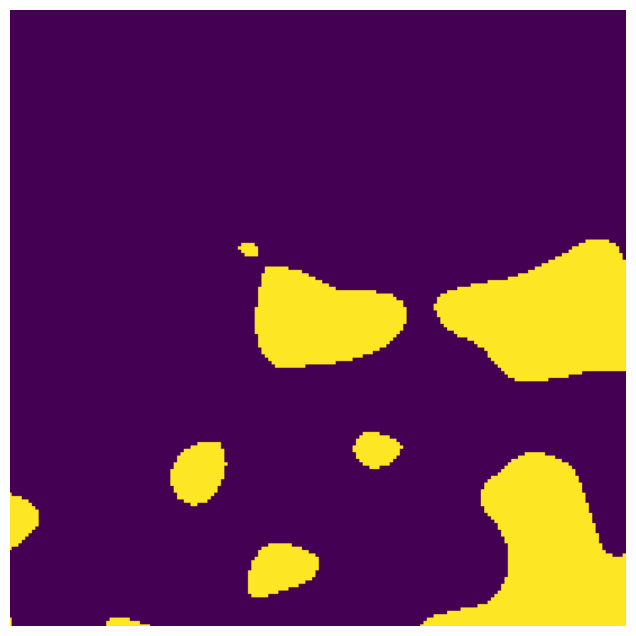

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))
plt.imshow(image_obj)
plt.axis("off")
plt.show()

In [18]:
from datasets import Image

ds_paths = ds.cast_column(
    "image",
    Image(decode=False)
)

path_sample = next(iter(ds_paths))

print(path_sample["image"])

{'path': 'hf://datasets/kostaspic/amfitrite-inland-waters-hab-sentinel2@88dda2242db358dc2464ef14a00e548acbd8d558/data/1000_2019-05-15/AOT_raw.tif', 'bytes': None}


In [19]:
from pathlib import PurePosixPath

image_path = path_sample["image"]["path"]

print("FULL PATH:")
print(image_path)

p = PurePosixPath(image_path)

print("\nFILENAME:")
print(p.name)

print("\nPARENT FOLDER:")
print(p.parent.name)

FULL PATH:
hf://datasets/kostaspic/amfitrite-inland-waters-hab-sentinel2@88dda2242db358dc2464ef14a00e548acbd8d558/data/1000_2019-05-15/AOT_raw.tif

FILENAME:
AOT_raw.tif

PARENT FOLDER:
1000_2019-05-15


In [20]:
EXPECTED_FILES = [
    "B01_raw.tif",
    "B02_raw.tif",
    "B03_raw.tif",
    "B04_raw.tif",
    "B05_raw.tif",
    "B06_raw.tif",
    "B07_raw.tif",
    "B08_raw.tif",
    "B8A_raw.tif",
    "B09_raw.tif",
    "B11_raw.tif",
    "B12_raw.tif",
    "SCL_raw.tif",
    "AOT_raw.tif",
    "WVP_raw.tif",
    "visual_raw.tif",
    "cyfi_prediction_map.png",
]

In [21]:
from huggingface_hub import hf_hub_download
import pandas as pd

REPO_ID = "kostaspic/amfitrite-inland-waters-hab-sentinel2"

summary_path = hf_hub_download(
    repo_id=REPO_ID,
    filename="dataset_summary_256x256pixels.xlsx",
    repo_type="dataset"
)

print("Downloaded summary to:")
print(summary_path)

dataset_summary_256x256pixels.xlsx: reconstructing file:   0%|          |  0.00B /  680kB            

dataset_summary_256x256pixels.xlsx: downloading bytes:           |  0.00B            

Downloaded summary to:
/root/.cache/huggingface/hub/datasets--kostaspic--amfitrite-inland-waters-hab-sentinel2/snapshots/88dda2242db358dc2464ef14a00e548acbd8d558/dataset_summary_256x256pixels.xlsx


In [22]:
summary = pd.read_excel(summary_path)

print("Shape:", summary.shape)

print("\nColumns:")
print(summary.columns.tolist())

display(summary.head())

Shape: (4684, 20)

Columns:
['uid', 'uid_CAML', 'case', 'item_id', 'date', 'lat', 'lon', 'abun', 'abun_class', 'per_clouds', 'category', 'training_priority', 'crop_row', 'crop_col', 'new_water_pixels', 'new_high_pred', 'new_mod_pred', 'new_low_pred', 'new_low_percentage', 'new_indicative_class']


,uid,uid_CAML,case,item_id,date,lat,lon,abun,abun_class,per_clouds,category,training_priority,crop_row,crop_col,new_water_pixels,new_high_pred,new_mod_pred,new_low_pred,new_low_percentage,new_indicative_class
0,1176_2017-10-31,[],1176,S2B_MSIL2A_20171031T160359_R097_T17RLK_2020101...,2017-10-31,26.946740,-82.023080,[],NaN,2.68,without_measurments,1,0,0,40834,0,0,428,1.000000,Low
1,78_2020-04-21,[],78,S2A_MSIL2A_20200421T165851_R069_T15TVK_2020092...,2020-04-21,44.868638,-93.524033,[],NaN,1.82,without_measurments,1,0,0,8602,0,0,84,1.000000,Low
2,2209_2018-05-13,[],2209,S2B_MSIL2A_20180513T171859_R012_T14TPR_2020101...,2018-05-13,45.441710,-97.264110,[],NaN,0.35,without_measurments,1,66,57,58032,0,0,590,1.000000,Low
3,372_2018-03-06,['nhdx'],372,S2A_MSIL2A_20180306T185231_R113_T10SFF_2020101...,2018-03-06,36.772300,-121.788000,[6065.0],High,0.73,with_measurments,1,0,0,24586,0,0,264,1.000000,Low
4,95_2019-04-15,['cwrw'],95,S2A_MSIL2A_20190415T161901_R040_T17TLG_2020100...,2019-04-15,41.726667,-83.150000,[8.320958831],Low,0.00,with_measurments,1,105,0,65536,0,122,554,0.819527,Moderate


In [23]:
print("Rows:", len(summary))

print(
    "Unique UIDs:",
    summary["uid"].nunique()
)

Rows: 4684
Unique UIDs: 4684


In [24]:
print(
    summary[
        [
            "uid",
            "case",
            "date",
            "lat",
            "lon",
            "abun",
            "abun_class",
            "category",
            "training_priority"
        ]
    ].head(10)
)

               uid  case        date        lat         lon           abun  \
0  1176_2017-10-31  1176  2017-10-31  26.946740  -82.023080             []   
1    78_2020-04-21    78  2020-04-21  44.868638  -93.524033             []   
2  2209_2018-05-13  2209  2018-05-13  45.441710  -97.264110             []   
3   372_2018-03-06   372  2018-03-06  36.772300 -121.788000       [6065.0]   
4    95_2019-04-15    95  2019-04-15  41.726667  -83.150000  [8.320958831]   
5   147_2019-09-03   147  2019-09-03  36.020000  -76.310000        [648.2]   
6   510_2021-04-30   510  2021-04-30  35.950000  -76.680000        [2.142]   
7   209_2020-10-02   209  2020-10-02  35.950000  -76.610000        [1.056]   
8   510_2021-05-15   510  2021-05-15  35.950000  -76.680000        [1.245]   
9  1387_2018-09-04  1387  2018-09-04  42.156700  -80.152500       [50.467]   

  abun_class             category  training_priority  
0        NaN  without_measurments                  1  
1        NaN  without_measurmen

In [26]:
print(
    summary["new_indicative_class"]
    .value_counts(dropna=False)
)
print(
    summary["training_priority"]
    .value_counts(dropna=False)
)
print(
    summary["category"]
    .value_counts(dropna=False)
)
print(
    summary["abun_class"]
    .value_counts(dropna=False)
)

new_indicative_class
High        1938
Low         1397
Moderate    1349
Name: count, dtype: int64
training_priority
1    3313
2    1371
Name: count, dtype: int64
category
without_measurments    2475
with_measurments       2209
Name: count, dtype: int64
abun_class
NaN         2475
High         925
Low          852
Moderate     432
Name: count, dtype: int64


In [27]:
print(summary["abun"].head(20))
print(
    summary["abun"].describe()
)

0                []
1                []
2                []
3          [6065.0]
4     [8.320958831]
5           [648.2]
6           [2.142]
7           [1.056]
8           [1.245]
9          [50.467]
10          [3.486]
11           [0.29]
12         [20.764]
13    [0.104886914]
14         [24.573]
15    [3.303937778]
16          [4.212]
17        [24.1665]
18          [1.045]
19         [24.566]
Name: abun, dtype: str
count     4684
unique    2145
top         []
freq      2475
Name: abun, dtype: object


In [28]:
crop_cols = [
    "crop_row",
    "crop_col",
    "new_water_pixels",
    "new_high_pred",
    "new_mod_pred",
    "new_low_pred",
    "new_low_percentage",
    "new_indicative_class"
]

display(summary[crop_cols].head())

,crop_row,crop_col,new_water_pixels,new_high_pred,new_mod_pred,new_low_pred,new_low_percentage,new_indicative_class
0,0,0,40834,0,0,428,1.000000,Low
1,0,0,8602,0,0,84,1.000000,Low
2,66,57,58032,0,0,590,1.000000,Low
3,0,0,24586,0,0,264,1.000000,Low
4,105,0,65536,0,122,554,0.819527,Moderate


In [30]:
import ast
import numpy as np
import pandas as pd

def parse_abundance(value):
    """
    Convert the string representation of an abundance list
    into a Python list of floats.
    """
    if pd.isna(value):
        return []

    if isinstance(value, list):
        return [float(x) for x in value]

    try:
        parsed = ast.literal_eval(str(value))

        if parsed is None:
            return []

        if isinstance(parsed, (list, tuple)):
            return [float(x) for x in parsed if x is not None]

        return [float(parsed)]

    except (ValueError, SyntaxError, TypeError):
        return []


summary["abun_values"] = summary["abun"].apply(parse_abundance)

print(summary[["abun", "abun_values"]].head(20))

             abun    abun_values
0              []             []
1              []             []
2              []             []
3        [6065.0]       [6065.0]
4   [8.320958831]  [8.320958831]
5         [648.2]        [648.2]
6         [2.142]        [2.142]
7         [1.056]        [1.056]
8         [1.245]        [1.245]
9        [50.467]       [50.467]
10        [3.486]        [3.486]
11         [0.29]         [0.29]
12       [20.764]       [20.764]
13  [0.104886914]  [0.104886914]
14       [24.573]       [24.573]
15  [3.303937778]  [3.303937778]
16        [4.212]        [4.212]
17      [24.1665]      [24.1665]
18        [1.045]        [1.045]
19       [24.566]       [24.566]


In [31]:
summary["abun_n"] = summary["abun_values"].apply(len)

summary["abun_min"] = summary["abun_values"].apply(
    lambda x: min(x) if x else np.nan
)

summary["abun_max"] = summary["abun_values"].apply(
    lambda x: max(x) if x else np.nan
)

summary["abun_mean"] = summary["abun_values"].apply(
    lambda x: np.mean(x) if x else np.nan
)

print(
    summary[
        [
            "uid",
            "abun_n",
            "abun_min",
            "abun_max",
            "abun_mean"
        ]
    ].head(20)
)

                uid  abun_n     abun_min     abun_max    abun_mean
0   1176_2017-10-31       0          NaN          NaN          NaN
1     78_2020-04-21       0          NaN          NaN          NaN
2   2209_2018-05-13       0          NaN          NaN          NaN
3    372_2018-03-06       1  6065.000000  6065.000000  6065.000000
4     95_2019-04-15       1     8.320959     8.320959     8.320959
5    147_2019-09-03       1   648.200000   648.200000   648.200000
6    510_2021-04-30       1     2.142000     2.142000     2.142000
7    209_2020-10-02       1     1.056000     1.056000     1.056000
8    510_2021-05-15       1     1.245000     1.245000     1.245000
9   1387_2018-09-04       1    50.467000    50.467000    50.467000
10   944_2020-08-08       1     3.486000     3.486000     3.486000
11   387_2021-05-20       1     0.290000     0.290000     0.290000
12   537_2018-06-07       1    20.764000    20.764000    20.764000
13  2098_2019-04-27       1     0.104887     0.104887     0.10

In [32]:
measured = summary[summary["abun_n"] > 0].copy()

print("Measured cases:", len(measured))

print(
    measured[
        [
            "abun_max",
            "abun_class",
            "new_indicative_class"
        ]
    ].head(20)
)

Measured cases: 2209
       abun_max abun_class new_indicative_class
3   6065.000000       High                  Low
4      8.320959        Low             Moderate
5    648.200000       High             Moderate
6      2.142000        Low             Moderate
7      1.056000        Low             Moderate
8      1.245000        Low             Moderate
9     50.467000   Moderate             Moderate
10     3.486000        Low             Moderate
11     0.290000        Low             Moderate
12    20.764000   Moderate             Moderate
13     0.104887        Low             Moderate
14    24.573000   Moderate             Moderate
15     3.303938        Low             Moderate
16     4.212000        Low             Moderate
17    24.166500   Moderate             Moderate
18     1.045000        Low                  Low
19    24.566000   Moderate             Moderate
20     2.718080        Low             Moderate
23     1.786139        Low                  Low
28    54.000000   M

In [33]:
print(
    measured.groupby("abun_class")["abun_max"].describe()
)

            count         mean          std     min        25%         50%  \
abun_class                                                                   
High        925.0  1895.425545  5439.083255  100.23  224.38000  509.267000   
Low         852.0     4.508829     5.315378    0.00    0.51895    1.969691   
Moderate    432.0    51.108209    22.438295   20.03   31.89925   48.132500   

                  75%          max  
abun_class                          
High        1543.3460  71813.89788  
Low            6.9575     19.86700  
Moderate      67.6480    100.00000  


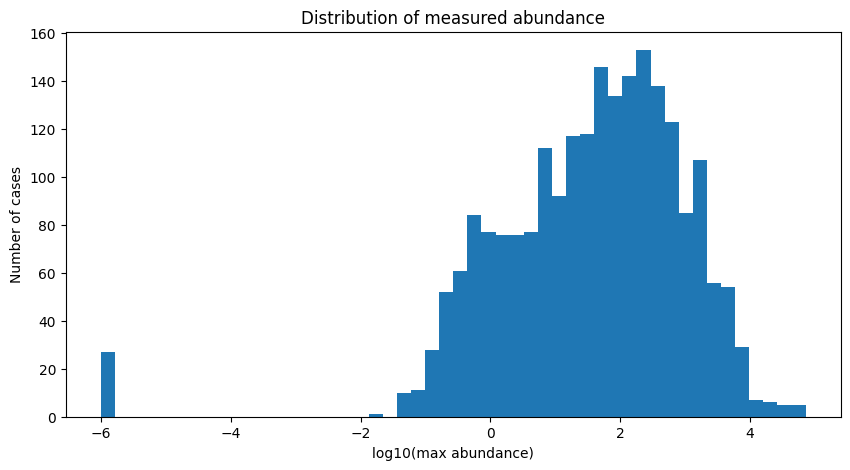

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.hist(
    np.log10(measured["abun_max"].clip(lower=1e-6)),
    bins=50
)

plt.xlabel("log10(max abundance)")
plt.ylabel("Number of cases")
plt.title("Distribution of measured abundance")

plt.show()

In [35]:
print("Unique cases:", summary["case"].nunique())
print("Unique UIDs:", summary["uid"].nunique())

Unique cases: 952
Unique UIDs: 4684


In [36]:
case_counts = summary["case"].value_counts()

print(case_counts.describe())
print("\nCases with multiple dates:")
print((case_counts > 1).sum())

count    952.000000
mean       4.920168
std        4.588416
min        1.000000
25%        1.000000
50%        4.000000
75%        7.000000
max       43.000000
Name: count, dtype: float64

Cases with multiple dates:
704


In [37]:
summary["date"] = pd.to_datetime(summary["date"])

print(summary["date"].describe())
print(
    summary["date"].dt.year.value_counts().sort_index()
)
print(
    summary["date"].dt.month.value_counts().sort_index()
)
print(summary["per_clouds"].describe())
print(
    summary["per_clouds"].isna().sum(),
    "missing cloud values"
)
print(
    summary["new_water_pixels"].describe()
)
print(
    summary["new_low_percentage"].describe()
)

count                          4684
mean     2019-03-02 19:41:45.550811
min             2017-01-29 00:00:00
25%             2017-11-28 00:00:00
50%             2019-03-23 00:00:00
75%             2020-03-30 06:00:00
max             2022-08-26 00:00:00
Name: date, dtype: object
date
2017    1251
2018     953
2019    1174
2020     866
2021     397
2022      43
Name: count, dtype: int64
date
1     143
2     200
3     363
4     326
5     440
6     449
7     663
8     790
9     544
10    383
11    236
12    147
Name: count, dtype: int64
count    4684.000000
mean        1.291655
std         1.851561
min         0.000000
25%         0.200000
50%         0.640000
75%         1.660000
max        53.020000
Name: per_clouds, dtype: float64
0 missing cloud values
count     4684.000000
mean     29850.092656
std      20361.265023
min       1716.000000
25%      11776.000000
50%      24164.500000
75%      45600.000000
max      65536.000000
Name: new_water_pixels, dtype: float64
count    4684.000000
me

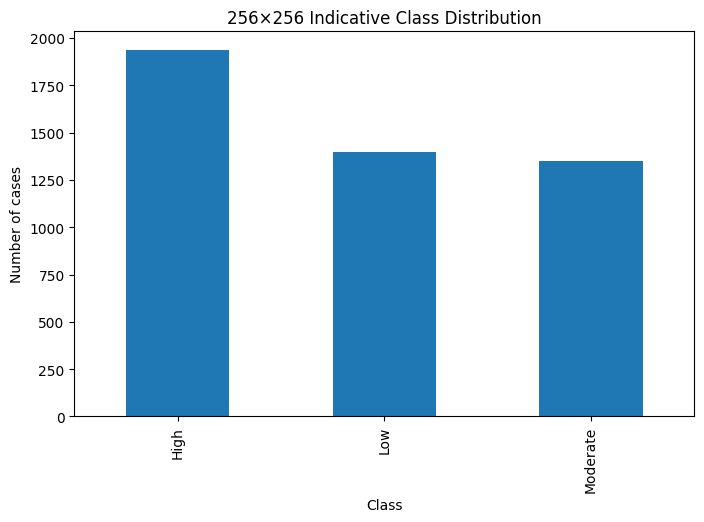

In [38]:
class_counts = summary["new_indicative_class"].value_counts()

plt.figure(figsize=(8, 5))

class_counts.plot(kind="bar")

plt.xlabel("Class")
plt.ylabel("Number of cases")
plt.title("256×256 Indicative Class Distribution")

plt.show()

In [39]:
pd.crosstab(
    summary["category"],
    summary["new_indicative_class"]
)
pd.crosstab(
    summary["abun_class"],
    summary["new_indicative_class"],
    dropna=False
)

new_indicative_class,High,Low,Moderate
abun_class,,,
High,716,39,170
Low,159,451,242
Moderate,222,59,151
NaN,841,848,786


In [40]:
from huggingface_hub import HfApi

REPO_ID = "kostaspic/amfitrite-inland-waters-hab-sentinel2"

api = HfApi()

repo_files = list(
    api.list_repo_tree(
        REPO_ID,
        path_in_repo="data",
        recursive=True,
        repo_type="dataset"
    )
)

print("Repository entries:", len(repo_files))

Repository entries: 93960


In [41]:
for item in repo_files[:20]:
    print(
        type(item).__name__,
        "|",
        item.path,
        "|",
        getattr(item, "size", None)
    )

RepoFolder | data/1000_2019-05-15 | None
RepoFolder | data/1000_2019-07-11 | None
RepoFolder | data/1000_2020-04-24 | None
RepoFolder | data/1000_2020-06-25 | None
RepoFolder | data/1000_2020-08-04 | None
RepoFolder | data/1000_2020-10-06 | None
RepoFolder | data/1001_2018-08-10 | None
RepoFolder | data/1001_2019-08-25 | None
RepoFolder | data/1001_2019-11-23 | None
RepoFolder | data/1001_2019-12-13 | None
RepoFolder | data/1001_2020-04-21 | None
RepoFolder | data/1001_2020-06-20 | None
RepoFolder | data/1001_2020-08-04 | None
RepoFolder | data/1001_2021-08-24 | None
RepoFolder | data/1004_2020-06-06 | None
RepoFolder | data/1004_2021-10-14 | None
RepoFolder | data/1005_2017-05-15 | None
RepoFolder | data/1005_2017-06-29 | None
RepoFolder | data/1005_2017-08-31 | None
RepoFolder | data/1005_2017-09-17 | None


In [42]:
from pathlib import PurePosixPath

file_records = []

for item in repo_files:

    path = item.path

    if not path.startswith("data/"):
        continue

    parts = PurePosixPath(path).parts

    # Expected:
    # data / UID / filename
    if len(parts) != 3:
        continue

    uid = parts[1]
    filename = parts[2]

    file_records.append({
        "uid": uid,
        "filename": filename,
        "path": path,
        "size_bytes": getattr(item, "size", None)
    })

file_manifest = pd.DataFrame(file_records)

print(file_manifest.shape)

display(file_manifest.head(20))

(89262, 4)


,uid,filename,path,size_bytes
0,1000_2019-05-15,AOT_raw.tif,data/1000_2019-05-15/AOT_raw.tif,267032
1,1000_2019-05-15,B01_raw.tif,data/1000_2019-05-15/B01_raw.tif,267032
2,1000_2019-05-15,B02_raw.tif,data/1000_2019-05-15/B02_raw.tif,267032
3,1000_2019-05-15,B03_raw.tif,data/1000_2019-05-15/B03_raw.tif,267032
4,1000_2019-05-15,B04_raw.tif,data/1000_2019-05-15/B04_raw.tif,267014
5,1000_2019-05-15,B05_raw.tif,data/1000_2019-05-15/B05_raw.tif,267032
6,1000_2019-05-15,B06_raw.tif,data/1000_2019-05-15/B06_raw.tif,267032
7,1000_2019-05-15,B07_raw.tif,data/1000_2019-05-15/B07_raw.tif,267032
8,1000_2019-05-15,B08_raw.tif,data/1000_2019-05-15/B08_raw.tif,267032
9,1000_2019-05-15,B09_raw.tif,data/1000_2019-05-15/B09_raw.tif,267032


In [43]:
files_per_case = (
    file_manifest
    .groupby("uid")
    .size()
)

print(files_per_case.describe())

print(
    "\nDistribution:"
)

print(
    files_per_case.value_counts().sort_index()
)

count    4698.0
mean       19.0
std         0.0
min        19.0
25%        19.0
50%        19.0
75%        19.0
max        19.0
dtype: float64

Distribution:
19    4698
Name: count, dtype: int64


In [44]:
file_counts = (
    file_manifest["filename"]
    .value_counts()
)

print(file_counts)

filename
AOT_raw.tif                     4698
B01_raw.tif                     4698
B02_raw.tif                     4698
B03_raw.tif                     4698
B04_raw.tif                     4698
B05_raw.tif                     4698
B06_raw.tif                     4698
B07_raw.tif                     4698
B08_raw.tif                     4698
B09_raw.tif                     4698
B11_raw.tif                     4698
B12_raw.tif                     4698
B8A_raw.tif                     4698
SCL_raw.tif                     4698
WVP_raw.tif                     4698
cyfi_lattice_predictions.csv    4698
cyfi_prediction_map.png         4698
metadata.json                   4698
visual_raw.tif                  4698
Name: count, dtype: int64


In [45]:
# ============================================
# STEP 16: Compare repository cases vs summary
# ============================================

summary_uids = set(summary["uid"].astype(str).str.strip())
repo_uids = set(file_manifest["uid"].astype(str).str.strip())

repo_not_in_summary = sorted(repo_uids - summary_uids)
summary_not_in_repo = sorted(summary_uids - repo_uids)

print("Summary unique UIDs:", len(summary_uids))
print("Repository unique UIDs:", len(repo_uids))

print("\nRepository cases NOT in 256x256 summary:")
print("Count:", len(repo_not_in_summary))
print(repo_not_in_summary)

print("\nSummary UIDs NOT found in repository:")
print("Count:", len(summary_not_in_repo))
print(summary_not_in_repo)

Summary unique UIDs: 4684
Repository unique UIDs: 4698

Repository cases NOT in 256x256 summary:
Count: 14
['115_2020-11-24', '115_2021-05-23', '161_2018-04-21', '170_2017-09-20', '1925_2018-08-30', '285_2018-07-10', '285_2019-07-20', '285_2020-05-10', '319_2020-10-17', '322_2020-04-14', '402_2019-04-21', '521_2017-08-23', '521_2017-09-04', '550_2021-05-20']

Summary UIDs NOT found in repository:
Count: 0
[]


In [46]:
# ============================================
# STEP 17: Required-file completeness
# ============================================

REQUIRED_FILES = [
    "B02_raw.tif",
    "B03_raw.tif",
    "B04_raw.tif",
    "B05_raw.tif",
    "B06_raw.tif",
    "B07_raw.tif",
    "B08_raw.tif",
    "B8A_raw.tif",
    "B11_raw.tif",
    "B12_raw.tif",
    "SCL_raw.tif",
    "cyfi_lattice_predictions.csv",
]

file_presence = (
    file_manifest[
        file_manifest["filename"].isin(REQUIRED_FILES)
    ]
    .groupby("uid")["filename"]
    .agg(set)
)

missing_cases = []

for uid, present_files in file_presence.items():
    missing = sorted(set(REQUIRED_FILES) - present_files)

    if missing:
        missing_cases.append({
            "uid": uid,
            "missing_files": missing
        })

missing_cases_df = pd.DataFrame(missing_cases)

print("Cases checked:", len(file_presence))
print("Cases with missing required files:", len(missing_cases_df))

if len(missing_cases_df) > 0:
    display(missing_cases_df.head(20))
else:
    print("✓ Every repository case has all required files.")

Cases checked: 4698
Cases with missing required files: 0
✓ Every repository case has all required files.


In [47]:
# ============================================
# STEP 18: File-size statistics
# ============================================

selected_for_training = file_manifest[
    file_manifest["filename"].isin(REQUIRED_FILES)
].copy()

size_stats = (
    selected_for_training
    .groupby("filename")["size_bytes"]
    .agg(
        count="count",
        min_bytes="min",
        median_bytes="median",
        mean_bytes="mean",
        max_bytes="max",
        total_bytes="sum"
    )
    .sort_values("total_bytes", ascending=False)
)

display(size_stats)

,count,min_bytes,median_bytes,mean_bytes,max_bytes,total_bytes
filename,,,,,,
B02_raw.tif,4698,35448,267032.0,261648.937846,267032,1229226710
B03_raw.tif,4698,35448,267032.0,261648.937846,267032,1229226710
B05_raw.tif,4698,35448,267032.0,261648.937846,267032,1229226710
B06_raw.tif,4698,35448,267032.0,261648.937846,267032,1229226710
B12_raw.tif,4698,35448,267032.0,261648.937846,267032,1229226710
B07_raw.tif,4698,35448,267032.0,261648.937846,267032,1229226710
B08_raw.tif,4698,35448,267032.0,261648.937846,267032,1229226710
B11_raw.tif,4698,35448,267032.0,261648.937846,267032,1229226710
B8A_raw.tif,4698,35448,267032.0,261648.937846,267032,1229226710


In [48]:
# Convert total sizes to MB / GB
size_stats["total_MB"] = size_stats["total_bytes"] / (1024**2)
size_stats["total_GB"] = size_stats["total_bytes"] / (1024**3)

display(
    size_stats[
        ["count", "total_MB", "total_GB"]
    ]
)

,count,total_MB,total_GB
filename,,,
B02_raw.tif,4698,1172.281942,1.144807
B03_raw.tif,4698,1172.281942,1.144807
B05_raw.tif,4698,1172.281942,1.144807
B06_raw.tif,4698,1172.281942,1.144807
B12_raw.tif,4698,1172.281942,1.144807
B07_raw.tif,4698,1172.281942,1.144807
B08_raw.tif,4698,1172.281942,1.144807
B11_raw.tif,4698,1172.281942,1.144807
B8A_raw.tif,4698,1172.281942,1.144807


In [49]:
total_selected_bytes = selected_for_training["size_bytes"].sum()

print(
    f"Total size of required files for all 4698 cases: "
    f"{total_selected_bytes / (1024**3):.2f} GB"
)

Total size of required files for all 4698 cases: 12.16 GB


In [50]:
# ============================================
# STEP 19: Build master case manifest
# ============================================

master_manifest = summary.copy()

# Make UID format consistent
master_manifest["uid"] = (
    master_manifest["uid"]
    .astype(str)
    .str.strip()
)

# Keep only files needed for the first model
required_manifest = file_manifest[
    file_manifest["filename"].isin(REQUIRED_FILES)
].copy()

# Convert filenames into columns
file_paths = (
    required_manifest
    .pivot(
        index="uid",
        columns="filename",
        values="path"
    )
    .reset_index()
)

# Merge metadata + file paths
master_manifest = master_manifest.merge(
    file_paths,
    on="uid",
    how="left",
    validate="one_to_one"
)

print("Master manifest shape:", master_manifest.shape)

display(master_manifest.head())

Master manifest shape: (4684, 37)


,uid,uid_CAML,case,item_id,date,lat,lon,abun,abun_class,per_clouds,...,B04_raw.tif,B05_raw.tif,B06_raw.tif,B07_raw.tif,B08_raw.tif,B11_raw.tif,B12_raw.tif,B8A_raw.tif,SCL_raw.tif,cyfi_lattice_predictions.csv
0,1176_2017-10-31,[],1176,S2B_MSIL2A_20171031T160359_R097_T17RLK_2020101...,2017-10-31,26.946740,-82.023080,[],NaN,2.68,...,data/1176_2017-10-31/B04_raw.tif,data/1176_2017-10-31/B05_raw.tif,data/1176_2017-10-31/B06_raw.tif,data/1176_2017-10-31/B07_raw.tif,data/1176_2017-10-31/B08_raw.tif,data/1176_2017-10-31/B11_raw.tif,data/1176_2017-10-31/B12_raw.tif,data/1176_2017-10-31/B8A_raw.tif,data/1176_2017-10-31/SCL_raw.tif,data/1176_2017-10-31/cyfi_lattice_predictions.csv
1,78_2020-04-21,[],78,S2A_MSIL2A_20200421T165851_R069_T15TVK_2020092...,2020-04-21,44.868638,-93.524033,[],NaN,1.82,...,data/78_2020-04-21/B04_raw.tif,data/78_2020-04-21/B05_raw.tif,data/78_2020-04-21/B06_raw.tif,data/78_2020-04-21/B07_raw.tif,data/78_2020-04-21/B08_raw.tif,data/78_2020-04-21/B11_raw.tif,data/78_2020-04-21/B12_raw.tif,data/78_2020-04-21/B8A_raw.tif,data/78_2020-04-21/SCL_raw.tif,data/78_2020-04-21/cyfi_lattice_predictions.csv
2,2209_2018-05-13,[],2209,S2B_MSIL2A_20180513T171859_R012_T14TPR_2020101...,2018-05-13,45.441710,-97.264110,[],NaN,0.35,...,data/2209_2018-05-13/B04_raw.tif,data/2209_2018-05-13/B05_raw.tif,data/2209_2018-05-13/B06_raw.tif,data/2209_2018-05-13/B07_raw.tif,data/2209_2018-05-13/B08_raw.tif,data/2209_2018-05-13/B11_raw.tif,data/2209_2018-05-13/B12_raw.tif,data/2209_2018-05-13/B8A_raw.tif,data/2209_2018-05-13/SCL_raw.tif,data/2209_2018-05-13/cyfi_lattice_predictions.csv
3,372_2018-03-06,['nhdx'],372,S2A_MSIL2A_20180306T185231_R113_T10SFF_2020101...,2018-03-06,36.772300,-121.788000,[6065.0],High,0.73,...,data/372_2018-03-06/B04_raw.tif,data/372_2018-03-06/B05_raw.tif,data/372_2018-03-06/B06_raw.tif,data/372_2018-03-06/B07_raw.tif,data/372_2018-03-06/B08_raw.tif,data/372_2018-03-06/B11_raw.tif,data/372_2018-03-06/B12_raw.tif,data/372_2018-03-06/B8A_raw.tif,data/372_2018-03-06/SCL_raw.tif,data/372_2018-03-06/cyfi_lattice_predictions.csv
4,95_2019-04-15,['cwrw'],95,S2A_MSIL2A_20190415T161901_R040_T17TLG_2020100...,2019-04-15,41.726667,-83.150000,[8.320958831],Low,0.00,...,data/95_2019-04-15/B04_raw.tif,data/95_2019-04-15/B05_raw.tif,data/95_2019-04-15/B06_raw.tif,data/95_2019-04-15/B07_raw.tif,data/95_2019-04-15/B08_raw.tif,data/95_2019-04-15/B11_raw.tif,data/95_2019-04-15/B12_raw.tif,data/95_2019-04-15/B8A_raw.tif,data/95_2019-04-15/SCL_raw.tif,data/95_2019-04-15/cyfi_lattice_predictions.csv


In [51]:
# ============================================
# STEP 20: Validate master manifest
# ============================================

print("Rows:", len(master_manifest))
print("Unique UIDs:", master_manifest["uid"].nunique())

print("\nMissing file-path values:")
print(
    master_manifest[REQUIRED_FILES]
    .isna()
    .sum()
)

print("\nDuplicate UIDs:", master_manifest["uid"].duplicated().sum())

Rows: 4684
Unique UIDs: 4684

Missing file-path values:
B02_raw.tif                     0
B03_raw.tif                     0
B04_raw.tif                     0
B05_raw.tif                     0
B06_raw.tif                     0
B07_raw.tif                     0
B08_raw.tif                     0
B8A_raw.tif                     0
B11_raw.tif                     0
B12_raw.tif                     0
SCL_raw.tif                     0
cyfi_lattice_predictions.csv    0
dtype: int64

Duplicate UIDs: 0


In [52]:
# ============================================
# STEP 21: Geographic case structure
# ============================================

case_stats = (
    master_manifest
    .groupby("case")
    .agg(
        observations=("uid", "count"),
        dates=("date", "nunique"),
        measured=("abun_n", lambda x: (x > 0).sum()),
        mean_water_pixels=("new_water_pixels", "mean"),
        mean_cloud=("per_clouds", "mean")
    )
    .reset_index()
)

print("Unique geographic cases:", len(case_stats))

display(
    case_stats.sort_values(
        "observations",
        ascending=False
    ).head(20)
)

Unique geographic cases: 952


,case,observations,dates,measured,mean_water_pixels,mean_cloud
99,235,43,43,43,43912.279070,1.338140
69,164,35,19,35,26416.200000,1.776286
53,136,33,33,33,39711.606061,1.386970
98,231,30,30,29,19716.033333,0.967000
13,43,30,30,30,16145.133333,0.951000
68,163,28,28,24,28712.357143,0.942857
146,349,26,26,26,9587.307692,0.528077
128,297,26,26,24,16983.384615,0.878846
265,630,24,24,24,26278.000000,1.354167
80,190,23,23,17,37770.652174,2.004783


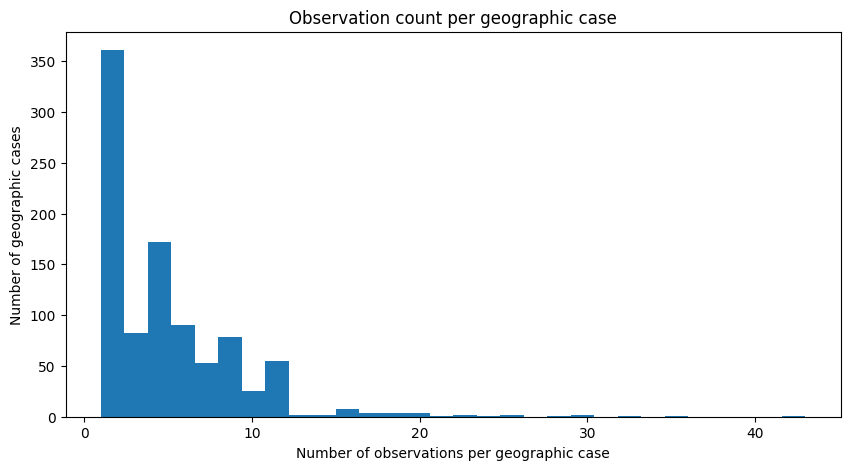

In [53]:
# ============================================
# STEP 22: Distribution of observations per case
# ============================================

plt.figure(figsize=(10, 5))

plt.hist(
    case_stats["observations"],
    bins=30
)

plt.xlabel("Number of observations per geographic case")
plt.ylabel("Number of geographic cases")
plt.title("Observation count per geographic case")

plt.show()

In [54]:
# ============================================
# STEP 23: Build case-level dataset
# ============================================

case_rows = []

for case_id, group in master_manifest.groupby("case"):

    # Most common indicative class for this geographic case
    dominant_class = group["new_indicative_class"].mode().iloc[0]

    # Whether this geographic case has at least one direct
    # CAML abundance measurement
    has_measurement = (group["abun_n"] > 0).any()

    # Fraction of observations having direct measurements
    measurement_fraction = (group["abun_n"] > 0).mean()

    # Number of observations/dates
    n_observations = len(group)

    # Date range
    min_date = group["date"].min()
    max_date = group["date"].max()

    case_rows.append({
        "case": case_id,
        "dominant_class": dominant_class,
        "has_measurement": has_measurement,
        "measurement_fraction": measurement_fraction,
        "n_observations": n_observations,
        "min_date": min_date,
        "max_date": max_date,
    })

case_df = pd.DataFrame(case_rows)

print("Number of geographic cases:", len(case_df))
display(case_df.head(20))

Number of geographic cases: 952


,case,dominant_class,has_measurement,measurement_fraction,n_observations,min_date,max_date
0,1,High,True,1.000000,20,2017-07-02,2021-08-05
1,6,High,True,1.000000,11,2020-06-06,2021-09-07
2,14,High,True,0.833333,6,2020-06-23,2021-10-14
3,15,High,True,1.000000,1,2018-09-19,2018-09-19
4,18,High,True,1.000000,15,2017-03-01,2021-09-06
5,19,High,True,0.125000,8,2017-08-02,2018-07-08
6,21,High,True,1.000000,9,2017-02-08,2018-04-19
7,24,Moderate,False,0.000000,10,2019-03-15,2020-10-23
8,28,High,True,1.000000,2,2017-08-24,2017-11-27
9,33,High,True,1.000000,2,2017-06-11,2019-07-21


In [55]:
# ============================================
# STEP 24: Create case-level stratification
# ============================================

case_df["measurement_status"] = np.where(
    case_df["has_measurement"],
    "measured",
    "unmeasured"
)

case_df["stratum"] = (
    case_df["dominant_class"].astype(str)
    + "_"
    + case_df["measurement_status"]
)

print("Case strata:")
print(case_df["stratum"].value_counts())

print("\nCross-tab:")
display(
    pd.crosstab(
        case_df["dominant_class"],
        case_df["measurement_status"]
    )
)

Case strata:
stratum
High_measured          388
Low_measured           224
High_unmeasured        104
Moderate_unmeasured     97
Low_unmeasured          73
Moderate_measured       66
Name: count, dtype: int64

Cross-tab:


measurement_status,measured,unmeasured
dominant_class,,
High,388,104
Low,224,73
Moderate,66,97


In [56]:
# ============================================
# STEP 25: Verify stratification groups
# ============================================

print(
    case_df["stratum"]
    .value_counts()
    .sort_index()
)

stratum
High_measured          388
High_unmeasured        104
Low_measured           224
Low_unmeasured          73
Moderate_measured       66
Moderate_unmeasured     97
Name: count, dtype: int64


In [57]:
# ============================================
# STEP 26: Geographic train/test split
# ============================================

from sklearn.model_selection import train_test_split

RANDOM_SEED = 42

train_cases, test_cases = train_test_split(
    case_df,
    test_size=0.15,
    random_state=RANDOM_SEED,
    stratify=case_df["stratum"]
)

print("Train geographic cases:", len(train_cases))
print("Test geographic cases:", len(test_cases))

Train geographic cases: 809
Test geographic cases: 143


In [58]:
# ============================================
# STEP 26B: Geographic train/validation split
# ============================================

# 15% of the complete dataset should be validation.
# Since 15% is already held out for test:
# 15 / 85 = 0.17647

train_cases, val_cases = train_test_split(
    train_cases,
    test_size=0.15 / 0.85,
    random_state=RANDOM_SEED,
    stratify=train_cases["stratum"]
)

print("Train geographic cases:", len(train_cases))
print("Validation geographic cases:", len(val_cases))
print("Test geographic cases:", len(test_cases))

print(
    "\nTotal:",
    len(train_cases) + len(val_cases) + len(test_cases)
)

Train geographic cases: 666
Validation geographic cases: 143
Test geographic cases: 143

Total: 952


In [59]:
# ============================================
# STEP 27: Assign split to every UID
# ============================================

train_case_ids = set(train_cases["case"])
val_case_ids = set(val_cases["case"])
test_case_ids = set(test_cases["case"])

master_manifest["split"] = master_manifest["case"].map(
    lambda x:
        "train" if x in train_case_ids
        else "val" if x in val_case_ids
        else "test" if x in test_case_ids
        else "ERROR"
)

print(master_manifest["split"].value_counts())

split
train    3391
val       650
test      643
Name: count, dtype: int64


In [60]:
# ============================================
# STEP 28: Leakage check
# ============================================

split_case_sets = {
    split: set(
        master_manifest.loc[
            master_manifest["split"] == split,
            "case"
        ]
    )
    for split in ["train", "val", "test"]
}

print("Train cases:", len(split_case_sets["train"]))
print("Val cases:", len(split_case_sets["val"]))
print("Test cases:", len(split_case_sets["test"]))

print(
    "\nTrain ∩ Val:",
    len(split_case_sets["train"] & split_case_sets["val"])
)

print(
    "Train ∩ Test:",
    len(split_case_sets["train"] & split_case_sets["test"])
)

print(
    "Val ∩ Test:",
    len(split_case_sets["val"] & split_case_sets["test"])
)

Train cases: 666
Val cases: 143
Test cases: 143

Train ∩ Val: 0
Train ∩ Test: 0
Val ∩ Test: 0


In [61]:
# ============================================
# STEP 29: Observation-level split statistics
# ============================================

split_stats = (
    master_manifest
    .groupby("split")
    .agg(
        observations=("uid", "count"),
        geographic_cases=("case", "nunique"),
        measured_observations=("abun_n", lambda x: (x > 0).sum()),
        mean_water_pixels=("new_water_pixels", "mean"),
        mean_cloud=("per_clouds", "mean"),
        mean_low_percentage=("new_low_percentage", "mean")
    )
)

display(split_stats)

,observations,geographic_cases,measured_observations,mean_water_pixels,mean_cloud,mean_low_percentage
split,,,,,,
test,643,143,322,28640.866252,1.159253,0.406554
train,3391,666,1631,29665.687998,1.329298,0.412351
val,650,143,256,32008.321538,1.226246,0.451716


In [62]:
# ============================================
# STEP 30: Indicative-class balance
# ============================================

class_distribution = pd.crosstab(
    master_manifest["split"],
    master_manifest["new_indicative_class"],
    normalize="index"
) * 100

display(
    class_distribution.round(2)
)

new_indicative_class,High,Low,Moderate
split,,,
test,43.08,29.39,27.53
train,41.55,29.87,28.58
val,38.77,30.00,31.23


In [63]:
# ============================================
# STEP 31: Measurement balance
# ============================================

master_manifest["measurement_status"] = np.where(
    master_manifest["abun_n"] > 0,
    "measured",
    "unmeasured"
)

measurement_distribution = pd.crosstab(
    master_manifest["split"],
    master_manifest["measurement_status"],
    normalize="index"
) * 100

display(
    measurement_distribution.round(2)
)

measurement_status,measured,unmeasured
split,,
test,50.08,49.92
train,48.10,51.90
val,39.38,60.62


In [64]:
# ============================================
# STEP 32: Temporal distribution
# ============================================

master_manifest["year"] = pd.to_datetime(
    master_manifest["date"]
).dt.year

year_distribution = pd.crosstab(
    master_manifest["split"],
    master_manifest["year"],
    normalize="index"
) * 100

display(
    year_distribution.round(2)
)

year,2017,2018,2019,2020,2021,2022
split,,,,,,
test,29.24,19.13,20.68,18.04,11.98,0.93
train,26.01,20.29,26.19,18.34,8.38,0.80
val,27.85,21.85,23.54,19.69,5.54,1.54


In [65]:
# ============================================
# STEP 33: Largest geographic cases
# ============================================

largest_cases = (
    master_manifest
    .groupby(["case", "split"])
    .size()
    .reset_index(name="observations")
    .sort_values("observations", ascending=False)
)

display(largest_cases.head(20))

,case,split,observations
99,235,test,43
69,164,train,35
53,136,train,33
98,231,train,30
13,43,train,30
68,163,test,28
146,349,train,26
128,297,train,26
265,630,train,24
80,190,val,23


In [66]:
# ============================================
# STEP 34: Case-balanced training weight
# ============================================

case_observation_counts = (
    master_manifest
    .groupby("case")["uid"]
    .transform("count")
)

master_manifest["case_weight"] = (
    1.0 / case_observation_counts
)

print(
    master_manifest[
        ["case", "uid", "case_weight"]
    ].head(20)
)

print(
    "\nCase weight range:",
    master_manifest["case_weight"].min(),
    "to",
    master_manifest["case_weight"].max()
)

    case              uid  case_weight
0   1176  1176_2017-10-31     0.125000
1     78    78_2020-04-21     0.166667
2   2209  2209_2018-05-13     0.333333
3    372   372_2018-03-06     0.058824
4     95    95_2019-04-15     0.200000
5    147   147_2019-09-03     0.076923
6    510   510_2021-04-30     0.125000
7    209   209_2020-10-02     0.111111
8    510   510_2021-05-15     0.125000
9   1387  1387_2018-09-04     0.500000
10   944   944_2020-08-08     0.090909
11   387   387_2021-05-20     0.043478
12   537   537_2018-06-07     0.058824
13  2098  2098_2019-04-27     0.500000
14   209   209_2021-05-15     0.111111
15  1214  1214_2019-08-10     1.000000
16   402   402_2019-12-07     0.055556
17  2205  2205_2017-07-15     1.000000
18   245   245_2020-09-10     0.142857
19   164   164_2021-05-27     0.028571

Case weight range: 0.023255813953488372 to 1.0


In [67]:
# ============================================
# STEP 35: Save master manifest
# ============================================

MANIFEST_PATH = "alga_trace_master_manifest.csv"

master_manifest.to_csv(
    MANIFEST_PATH,
    index=False
)

print("Saved:", MANIFEST_PATH)
print("Rows:", len(master_manifest))
print("Columns:", len(master_manifest.columns))

Saved: alga_trace_master_manifest.csv
Rows: 4684
Columns: 41


In [68]:
# ============================================
# STEP 36: Inspect 256x256 crop coordinates
# ============================================

crop_cols = [
    "crop_row",
    "crop_col"
]

print(master_manifest[crop_cols].describe())

print("\nMissing values:")
print(master_manifest[crop_cols].isna().sum())

print("\nUnique crop_row values:", master_manifest["crop_row"].nunique())
print("Unique crop_col values:", master_manifest["crop_col"].nunique())

print("\nFirst 20 crop coordinates:")
display(
    master_manifest[
        ["uid", "crop_row", "crop_col"]
    ].head(20)
)

          crop_row     crop_col
count  4684.000000  4684.000000
mean     44.415457    40.858454
std      45.628609    44.757250
min       0.000000     0.000000
25%       0.000000     0.000000
50%      30.000000    20.000000
75%      99.000000    90.000000
max     109.000000   109.000000

Missing values:
crop_row    0
crop_col    0
dtype: int64

Unique crop_row values: 109
Unique crop_col values: 109

First 20 crop coordinates:


,uid,crop_row,crop_col
0,1176_2017-10-31,0,0
1,78_2020-04-21,0,0
2,2209_2018-05-13,66,57
3,372_2018-03-06,0,0
4,95_2019-04-15,105,0
5,147_2019-09-03,0,105
6,510_2021-04-30,65,20
7,209_2020-10-02,45,105
8,510_2021-05-15,35,0
9,1387_2018-09-04,105,105


In [69]:
# ============================================
# STEP 36: Inspect 256x256 crop coordinates
# ============================================

crop_cols = [
    "crop_row",
    "crop_col"
]

print(master_manifest[crop_cols].describe())

print("\nMissing values:")
print(master_manifest[crop_cols].isna().sum())

print("\nUnique crop_row values:", master_manifest["crop_row"].nunique())
print("Unique crop_col values:", master_manifest["crop_col"].nunique())

print("\nFirst 20 crop coordinates:")
display(
    master_manifest[
        ["uid", "crop_row", "crop_col"]
    ].head(20)
)

          crop_row     crop_col
count  4684.000000  4684.000000
mean     44.415457    40.858454
std      45.628609    44.757250
min       0.000000     0.000000
25%       0.000000     0.000000
50%      30.000000    20.000000
75%      99.000000    90.000000
max     109.000000   109.000000

Missing values:
crop_row    0
crop_col    0
dtype: int64

Unique crop_row values: 109
Unique crop_col values: 109

First 20 crop coordinates:


,uid,crop_row,crop_col
0,1176_2017-10-31,0,0
1,78_2020-04-21,0,0
2,2209_2018-05-13,66,57
3,372_2018-03-06,0,0
4,95_2019-04-15,105,0
5,147_2019-09-03,0,105
6,510_2021-04-30,65,20
7,209_2020-10-02,45,105
8,510_2021-05-15,35,0
9,1387_2018-09-04,105,105


In [70]:
# ============================================
# STEP 36: Inspect 256x256 crop coordinates
# ============================================

crop_cols = [
    "crop_row",
    "crop_col"
]

print(master_manifest[crop_cols].describe())

print("\nMissing values:")
print(master_manifest[crop_cols].isna().sum())

print("\nUnique crop_row values:", master_manifest["crop_row"].nunique())
print("Unique crop_col values:", master_manifest["crop_col"].nunique())

print("\nFirst 20 crop coordinates:")
display(
    master_manifest[
        ["uid", "crop_row", "crop_col"]
    ].head(20)
)

          crop_row     crop_col
count  4684.000000  4684.000000
mean     44.415457    40.858454
std      45.628609    44.757250
min       0.000000     0.000000
25%       0.000000     0.000000
50%      30.000000    20.000000
75%      99.000000    90.000000
max     109.000000   109.000000

Missing values:
crop_row    0
crop_col    0
dtype: int64

Unique crop_row values: 109
Unique crop_col values: 109

First 20 crop coordinates:


,uid,crop_row,crop_col
0,1176_2017-10-31,0,0
1,78_2020-04-21,0,0
2,2209_2018-05-13,66,57
3,372_2018-03-06,0,0
4,95_2019-04-15,105,0
5,147_2019-09-03,0,105
6,510_2021-04-30,65,20
7,209_2020-10-02,45,105
8,510_2021-05-15,35,0
9,1387_2018-09-04,105,105


In [71]:
# ============================================
# STEP 36: Inspect 256x256 crop coordinates
# ============================================

crop_cols = [
    "crop_row",
    "crop_col"
]

print(master_manifest[crop_cols].describe())

print("\nMissing values:")
print(master_manifest[crop_cols].isna().sum())

print("\nUnique crop_row values:", master_manifest["crop_row"].nunique())
print("Unique crop_col values:", master_manifest["crop_col"].nunique())

print("\nFirst 20 crop coordinates:")
display(
    master_manifest[
        ["uid", "crop_row", "crop_col"]
    ].head(20)
)

          crop_row     crop_col
count  4684.000000  4684.000000
mean     44.415457    40.858454
std      45.628609    44.757250
min       0.000000     0.000000
25%       0.000000     0.000000
50%      30.000000    20.000000
75%      99.000000    90.000000
max     109.000000   109.000000

Missing values:
crop_row    0
crop_col    0
dtype: int64

Unique crop_row values: 109
Unique crop_col values: 109

First 20 crop coordinates:


,uid,crop_row,crop_col
0,1176_2017-10-31,0,0
1,78_2020-04-21,0,0
2,2209_2018-05-13,66,57
3,372_2018-03-06,0,0
4,95_2019-04-15,105,0
5,147_2019-09-03,0,105
6,510_2021-04-30,65,20
7,209_2020-10-02,45,105
8,510_2021-05-15,35,0
9,1387_2018-09-04,105,105


In [72]:
# ============================================
# STEP 38: Water coverage × class
# ============================================

water_class_stats = (
    master_manifest
    .groupby("new_indicative_class")["new_water_pixels"]
    .describe()
)

display(water_class_stats)

,count,mean,std,min,25%,50%,75%,max
new_indicative_class,,,,,,,,
High,1938.0,25543.346749,16104.095569,3624.0,11077.5,22652.0,38207.5,65520.0
Low,1397.0,38280.646385,24987.075163,1716.0,12536.0,35576.0,65536.0,65536.0
Moderate,1349.0,27306.719792,17726.424952,3440.0,12036.0,22632.0,41552.0,65536.0


In [73]:
# ============================================
# STEP 38B: Low-water cases by class
# ============================================

LOW_WATER_THRESHOLD = 10000

low_water_class = pd.crosstab(
    master_manifest["new_indicative_class"],
    master_manifest["new_water_pixels"] < LOW_WATER_THRESHOLD,
    normalize="index"
) * 100

display(low_water_class.round(2))

new_water_pixels,False,True
new_indicative_class,,
High,78.84,21.16
Low,83.68,16.32
Moderate,82.65,17.35


In [74]:
# ============================================
# STEP 39: Pin dataset revision
# ============================================

REPO_ID = "kostaspic/amfitrite-inland-waters-hab-sentinel2"

REVISION = (
    "88dda2242db358dc2464ef14a00e548acbd8d558"
)

print("Repository:", REPO_ID)
print("Revision:", REVISION)

Repository: kostaspic/amfitrite-inland-waters-hab-sentinel2
Revision: 88dda2242db358dc2464ef14a00e548acbd8d558


In [75]:
# ============================================
# STEP 40: Select representative cases
# ============================================

representative_cases = {}

for cls in ["High", "Moderate", "Low"]:

    candidates = master_manifest[
        (master_manifest["split"] == "train") &
        (master_manifest["abun_class"] == cls)
    ]

    if len(candidates) > 0:
        representative_cases[cls] = candidates.iloc[0]["uid"]


# Add an unmeasured example
unmeasured = master_manifest[
    (master_manifest["split"] == "train") &
    (master_manifest["abun_n"] == 0)
]

if len(unmeasured) > 0:
    representative_cases["Unmeasured"] = (
        unmeasured.iloc[0]["uid"]
    )

print(representative_cases)

{'High': '372_2018-03-06', 'Moderate': '164_2021-05-27', 'Low': '95_2019-04-15', 'Unmeasured': '78_2020-04-21'}


In [77]:
# ============================================
# STEP 41: Download representative CyFi files
# ============================================

from huggingface_hub import hf_hub_download

cyfi_local_paths = {}

for label, uid in representative_cases.items():

    path = hf_hub_download(
        repo_id=REPO_ID,
        filename=f"data/{uid}/cyfi_lattice_predictions.csv",
        revision=REVISION,
        repo_type="dataset"
    )

    cyfi_local_paths[label] = path

    print(label, "→", path)

cyfi_lattice_predictions.csv:   0%|          | 0.00/22.8k [00:00<?, ?B/s]

High → /root/.cache/huggingface/hub/datasets--kostaspic--amfitrite-inland-waters-hab-sentinel2/snapshots/88dda2242db358dc2464ef14a00e548acbd8d558/data/372_2018-03-06/cyfi_lattice_predictions.csv


cyfi_lattice_predictions.csv:   0%|          | 0.00/24.1k [00:00<?, ?B/s]

Moderate → /root/.cache/huggingface/hub/datasets--kostaspic--amfitrite-inland-waters-hab-sentinel2/snapshots/88dda2242db358dc2464ef14a00e548acbd8d558/data/164_2021-05-27/cyfi_lattice_predictions.csv


cyfi_lattice_predictions.csv:   0%|          | 0.00/94.5k [00:00<?, ?B/s]

Low → /root/.cache/huggingface/hub/datasets--kostaspic--amfitrite-inland-waters-hab-sentinel2/snapshots/88dda2242db358dc2464ef14a00e548acbd8d558/data/95_2019-04-15/cyfi_lattice_predictions.csv


cyfi_lattice_predictions.csv:   0%|          | 0.00/6.81k [00:00<?, ?B/s]

Unmeasured → /root/.cache/huggingface/hub/datasets--kostaspic--amfitrite-inland-waters-hab-sentinel2/snapshots/88dda2242db358dc2464ef14a00e548acbd8d558/data/78_2020-04-21/cyfi_lattice_predictions.csv


In [78]:
# ============================================
# STEP 42: Inspect CyFi CSV structure
# ============================================

for label, path in cyfi_local_paths.items():

    cyfi = pd.read_csv(path)

    print("\n" + "=" * 70)
    print(label)
    print("Shape:", cyfi.shape)
    print("Columns:")
    print(cyfi.columns.tolist())

    display(cyfi.head(10))


High
Shape: (336, 7)
Columns:
['sample_id', 'latitude', 'longitude', 'density_cells_per_ml', 'severity', 'pixel_row', 'pixel_col']


,sample_id,latitude,longitude,density_cells_per_ml,severity,pixel_row,pixel_col
0,sample_0,36.788971,-121.808213,1253.0,low,0,0
1,sample_1,36.788960,-121.807093,1366.0,low,0,10
2,sample_2,36.788948,-121.805972,1555.0,low,0,20
3,sample_3,36.788937,-121.804852,3886.0,low,0,30
4,sample_4,36.788926,-121.803731,6026.0,low,0,40
5,sample_5,36.788915,-121.802611,6026.0,low,0,50
6,sample_6,36.788903,-121.801490,6026.0,low,0,60
7,sample_7,36.788892,-121.800369,8620.0,low,0,70
8,sample_8,36.788881,-121.799249,8620.0,low,0,80
9,sample_9,36.788869,-121.798128,8620.0,low,0,90



Moderate
Shape: (354, 7)
Columns:
['sample_id', 'latitude', 'longitude', 'density_cells_per_ml', 'severity', 'pixel_row', 'pixel_col']


,sample_id,latitude,longitude,density_cells_per_ml,severity,pixel_row,pixel_col
0,sample_0,41.719439,-85.044115,13985.0,low,0,0
1,sample_1,41.719337,-85.038107,12760.0,low,0,50
2,sample_2,41.719316,-85.036906,11674.0,low,0,60
3,sample_3,41.718539,-85.044142,21868.0,moderate,10,0
4,sample_4,41.718457,-85.039336,20065.0,moderate,10,40
5,sample_5,41.718436,-85.038135,18255.0,low,10,50
6,sample_6,41.718416,-85.036933,12374.0,low,10,60
7,sample_7,41.717639,-85.044170,26049.0,moderate,20,0
8,sample_8,41.717598,-85.041767,25488.0,moderate,20,20
9,sample_9,41.717577,-85.040565,23716.0,moderate,20,30



Low
Shape: (1369, 7)
Columns:
['sample_id', 'latitude', 'longitude', 'density_cells_per_ml', 'severity', 'pixel_row', 'pixel_col']


,sample_id,latitude,longitude,density_cells_per_ml,severity,pixel_row,pixel_col
0,sample_0,41.742656,-83.172447,19237.0,low,0,0
1,sample_1,41.742679,-83.171246,19212.0,low,0,10
2,sample_2,41.742702,-83.170044,19212.0,low,0,20
3,sample_3,41.742725,-83.168842,19212.0,low,0,30
4,sample_4,41.742747,-83.167640,19237.0,low,0,40
5,sample_5,41.742770,-83.166438,19237.0,low,0,50
6,sample_6,41.742793,-83.165237,19371.0,low,0,60
7,sample_7,41.742815,-83.164035,19106.0,low,0,70
8,sample_8,41.742838,-83.162833,19106.0,low,0,80
9,sample_9,41.742860,-83.161631,19106.0,low,0,90



Unmeasured
Shape: (101, 7)
Columns:
['sample_id', 'latitude', 'longitude', 'density_cells_per_ml', 'severity', 'pixel_row', 'pixel_col']


,sample_id,latitude,longitude,density_cells_per_ml,severity,pixel_row,pixel_col
0,sample_0,44.884992,-93.537210,6335.0,low,0,80
1,sample_1,44.884998,-93.535944,5925.0,low,0,90
2,sample_2,44.884092,-93.537202,8313.0,low,10,80
3,sample_3,44.884098,-93.535936,7938.0,low,10,90
4,sample_4,44.884104,-93.534669,7823.0,low,10,100
5,sample_5,44.883192,-93.537193,7655.0,low,20,80
6,sample_6,44.883198,-93.535927,7766.0,low,20,90
7,sample_7,44.883204,-93.534661,7439.0,low,20,100
8,sample_8,44.883210,-93.533395,7439.0,low,20,110
9,sample_9,44.882292,-93.537185,8053.0,low,30,80


In [79]:
# ============================================
# STEP 43: CyFi numerical summary
# ============================================

for label, path in cyfi_local_paths.items():

    cyfi = pd.read_csv(path)

    print("\n" + "=" * 70)
    print(label)

    display(cyfi.describe(include="all"))


High


,sample_id,latitude,longitude,density_cells_per_ml,severity,pixel_row,pixel_col
count,336,336.000000,336.000000,336.000000,336,336.000000,336.000000
unique,336,NaN,NaN,NaN,3,NaN,NaN
top,sample_0,NaN,NaN,NaN,low,NaN,NaN
freq,1,NaN,NaN,NaN,323,NaN,NaN
mean,NaN,36.774950,-121.803615,9692.026786,NaN,155.029762,42.976190
std,NaN,0.009386,0.003430,15364.967193,NaN,104.272887,30.145112
min,NaN,36.756457,-121.808716,1234.000000,NaN,0.000000,0.000000
25%,NaN,36.767304,-121.806339,6612.000000,NaN,60.000000,20.000000
50%,NaN,36.776257,-121.803962,9259.000000,NaN,140.000000,40.000000
75%,NaN,36.783453,-121.801501,10507.250000,NaN,240.000000,60.000000



Moderate


,sample_id,latitude,longitude,density_cells_per_ml,severity,pixel_row,pixel_col
count,354,354.000000,354.000000,354.000000,354,354.000000,354.000000
unique,354,NaN,NaN,NaN,2,NaN,NaN
top,sample_0,NaN,NaN,NaN,low,NaN,NaN
freq,1,NaN,NaN,NaN,329,NaN,NaN
mean,NaN,41.700009,-85.030915,12678.042373,NaN,213.220339,114.745763
std,NaN,0.008785,0.008723,4895.275774,NaN,96.469238,74.053558
min,NaN,41.686517,-85.044333,3859.000000,NaN,0.000000,0.000000
25%,NaN,41.693910,-85.038648,8621.250000,NaN,162.500000,50.000000
50%,NaN,41.698354,-85.030398,12831.500000,NaN,230.000000,120.000000
75%,NaN,41.704714,-85.023405,14331.000000,NaN,280.000000,180.000000



Low


,sample_id,latitude,longitude,density_cells_per_ml,severity,pixel_row,pixel_col
count,1369,1369.000000,1369.000000,1369.000000,1369,1369.0000,1369.0000
unique,1369,NaN,NaN,NaN,2,NaN,NaN
top,sample_0,NaN,NaN,NaN,low,NaN,NaN
freq,1,NaN,NaN,NaN,1237,NaN,NaN
mean,NaN,41.726861,-83.150274,17471.934989,NaN,180.0000,180.0000
std,NaN,0.009617,0.012837,2090.815825,NaN,106.8098,106.8098
min,NaN,41.710254,-83.172447,13535.000000,NaN,0.0000,0.0000
25%,NaN,41.718559,-83.161360,15447.000000,NaN,90.0000,90.0000
50%,NaN,41.726862,-83.150274,18259.000000,NaN,180.0000,180.0000
75%,NaN,41.735165,-83.139192,19232.000000,NaN,270.0000,270.0000



Unmeasured


,sample_id,latitude,longitude,density_cells_per_ml,severity,pixel_row,pixel_col
count,101,101.000000,101.000000,101.000000,101,101.000000,101.000000
unique,101,NaN,NaN,NaN,3,NaN,NaN
top,sample_0,NaN,NaN,NaN,low,NaN,NaN
freq,1,NaN,NaN,NaN,86,NaN,NaN
mean,NaN,44.872846,-93.530918,19834.287129,NaN,135.247525,128.811881
std,NaN,0.009871,0.006671,47154.895282,NaN,109.632058,52.750111
min,NaN,44.852550,-93.547058,3661.000000,NaN,0.000000,0.000000
25%,NaN,44.869742,-93.535902,5373.000000,NaN,50.000000,90.000000
50%,NaN,44.876020,-93.529572,6397.000000,NaN,100.000000,140.000000
75%,NaN,44.880492,-93.527023,7772.000000,NaN,170.000000,160.000000


In [80]:
# ============================================
# STEP 44: CyFi density distribution
# ============================================

for label, path in cyfi_local_paths.items():

    cyfi = pd.read_csv(path)

    if "density_cells_per_ml" in cyfi.columns:

        density = pd.to_numeric(
            cyfi["density_cells_per_ml"],
            errors="coerce"
        )

        print("\n" + "=" * 70)
        print(label)

        print("Valid density values:", density.notna().sum())
        print("Missing density values:", density.isna().sum())

        print(
            density.describe()
        )

    else:
        print(
            label,
            "does not contain density_cells_per_ml"
        )


High
Valid density values: 336
Missing density values: 0
count       336.000000
mean       9692.026786
std       15364.967193
min        1234.000000
25%        6612.000000
50%        9259.000000
75%       10507.250000
max      268096.000000
Name: density_cells_per_ml, dtype: float64

Moderate
Valid density values: 354
Missing density values: 0
count      354.000000
mean     12678.042373
std       4895.275774
min       3859.000000
25%       8621.250000
50%      12831.500000
75%      14331.000000
max      32018.000000
Name: density_cells_per_ml, dtype: float64

Low
Valid density values: 1369
Missing density values: 0
count     1369.000000
mean     17471.934989
std       2090.815825
min      13535.000000
25%      15447.000000
50%      18259.000000
75%      19232.000000
max      21755.000000
Name: density_cells_per_ml, dtype: float64

Unmeasured
Valid density values: 101
Missing density values: 0
count       101.000000
mean      19834.287129
std       47154.895282
min        3661.000000
2

In [81]:
# ============================================
# STEP 45: Check CyFi spatial coordinates
# ============================================

for label, path in cyfi_local_paths.items():

    cyfi = pd.read_csv(path)

    print("\n" + "=" * 70)
    print(label)

    if {
        "pixel_row",
        "pixel_col"
    }.issubset(cyfi.columns):

        print(
            cyfi[
                ["pixel_row", "pixel_col"]
            ].describe()
        )

        invalid = cyfi[
            (cyfi["pixel_row"] < 0) |
            (cyfi["pixel_row"] >= 365) |
            (cyfi["pixel_col"] < 0) |
            (cyfi["pixel_col"] >= 365)
        ]

        print(
            "Coordinates outside 365x365:",
            len(invalid)
        )

    else:
        print("pixel_row/pixel_col not found.")


High
        pixel_row   pixel_col
count  336.000000  336.000000
mean   155.029762   42.976190
std    104.272887   30.145112
min      0.000000    0.000000
25%     60.000000   20.000000
50%    140.000000   40.000000
75%    240.000000   60.000000
max    360.000000  120.000000
Coordinates outside 365x365: 0

Moderate
        pixel_row   pixel_col
count  354.000000  354.000000
mean   213.220339  114.745763
std     96.469238   74.053558
min      0.000000    0.000000
25%    162.500000   50.000000
50%    230.000000  120.000000
75%    280.000000  180.000000
max    360.000000  360.000000
Coordinates outside 365x365: 0

Low
       pixel_row  pixel_col
count  1369.0000  1369.0000
mean    180.0000   180.0000
std     106.8098   106.8098
min       0.0000     0.0000
25%      90.0000    90.0000
50%     180.0000   180.0000
75%     270.0000   270.0000
max     360.0000   360.0000
Coordinates outside 365x365: 0

Unmeasured
        pixel_row   pixel_col
count  101.000000  101.000000
mean   135.247525  128

In [82]:
# ============================================
# STEP 46: Final crop + geometry validation
# ============================================

print("Crop coordinate statistics:")
display(
    master_manifest[
        ["crop_row", "crop_col"]
    ].describe()
)

print("\nMissing crop coordinates:")
print(
    master_manifest[
        ["crop_row", "crop_col"]
    ].isna().sum()
)

invalid_crop = master_manifest[
    (master_manifest["crop_row"] < 0) |
    (master_manifest["crop_row"] > 109) |
    (master_manifest["crop_col"] < 0) |
    (master_manifest["crop_col"] > 109)
]

print("\nInvalid crop coordinates:", len(invalid_crop))

if len(invalid_crop) == 0:
    print("✓ All crops are valid 365x365 → 256x256.")
else:
    display(
        invalid_crop[
            ["uid", "crop_row", "crop_col"]
        ].head(20)
    )

print("\nCrop row modulo 10:")
print(
    master_manifest["crop_row"].mod(10).value_counts().sort_index()
)

print("\nCrop col modulo 10:")
print(
    master_manifest["crop_col"].mod(10).value_counts().sort_index()
)

Crop coordinate statistics:


,crop_row,crop_col
count,4684.000000,4684.000000
mean,44.415457,40.858454
std,45.628609,44.757250
min,0.000000,0.000000
25%,0.000000,0.000000
50%,30.000000,20.000000
75%,99.000000,90.000000
max,109.000000,109.000000



Missing crop coordinates:
crop_row    0
crop_col    0
dtype: int64

Invalid crop coordinates: 0
✓ All crops are valid 365x365 → 256x256.

Crop row modulo 10:
crop_row
0    2307
1      72
2      70
3      66
4      63
5     613
6     159
7     122
8     131
9    1081
Name: count, dtype: int64

Crop col modulo 10:
crop_col
0    2391
1      85
2      80
3      98
4      55
5     590
6     100
7     150
8     123
9    1012
Name: count, dtype: int64


In [83]:
# ============================================
# STEP 47: Select one representative case
# ============================================

test_uid = representative_cases["High"]

test_row = master_manifest[
    master_manifest["uid"] == test_uid
].iloc[0]

print("Testing UID:", test_uid)
print("Case:", test_row["case"])
print("Split:", test_row["split"])
print("Crop row:", test_row["crop_row"])
print("Crop col:", test_row["crop_col"])
print("Indicative class:", test_row["new_indicative_class"])
print("Measured abundance:", test_row["abun_values"])

Testing UID: 372_2018-03-06
Case: 372
Split: train
Crop row: 0
Crop col: 0
Indicative class: Low
Measured abundance: [6065.0]


In [84]:
# ============================================
# STEP 48: Download one complete spectral case
# ============================================

from huggingface_hub import hf_hub_download

BANDS = [
    "B02",
    "B03",
    "B04",
    "B05",
    "B06",
    "B07",
    "B08",
    "B8A",
    "B11",
    "B12",
]

downloaded_paths = {}

for band in BANDS + ["SCL"]:

    filename = f"data/{test_uid}/{band}_raw.tif"

    local_path = hf_hub_download(
        repo_id=REPO_ID,
        filename=filename,
        revision=REVISION,
        repo_type="dataset"
    )

    downloaded_paths[band] = local_path

    print(
        f"{band:>3} → {local_path}"
    )

data/372_2018-03-06/B02_raw.tif: reconstructing file:   0%|          |  0.00B /  267kB            

data/372_2018-03-06/B02_raw.tif: downloading bytes:           |  0.00B            

B02 → /root/.cache/huggingface/hub/datasets--kostaspic--amfitrite-inland-waters-hab-sentinel2/snapshots/88dda2242db358dc2464ef14a00e548acbd8d558/data/372_2018-03-06/B02_raw.tif


data/372_2018-03-06/B03_raw.tif: reconstructing file:   0%|          |  0.00B /  267kB            

data/372_2018-03-06/B03_raw.tif: downloading bytes:           |  0.00B            

...

data/372_2018-03-06/B12_raw.tif: downloading bytes:           |  0.00B            

B12 → /root/.cache/huggingface/hub/datasets--kostaspic--amfitrite-inland-waters-hab-sentinel2/snapshots/88dda2242db358dc2464ef14a00e548acbd8d558/data/372_2018-03-06/B12_raw.tif


data/372_2018-03-06/SCL_raw.tif: reconstructing file:   0%|          |  0.00B /  134kB            

data/372_2018-03-06/SCL_raw.tif: downloading bytes:           |  0.00B            

SCL → /root/.cache/huggingface/hub/datasets--kostaspic--amfitrite-inland-waters-hab-sentinel2/snapshots/88dda2242db358dc2464ef14a00e548acbd8d558/data/372_2018-03-06/SCL_raw.tif


In [85]:
# ============================================
# STEP 48: Download one complete spectral case
# ============================================

from huggingface_hub import hf_hub_download

BANDS = [
    "B02",
    "B03",
    "B04",
    "B05",
    "B06",
    "B07",
    "B08",
    "B8A",
    "B11",
    "B12",
]

downloaded_paths = {}

for band in BANDS + ["SCL"]:

    filename = f"data/{test_uid}/{band}_raw.tif"

    local_path = hf_hub_download(
        repo_id=REPO_ID,
        filename=filename,
        revision=REVISION,
        repo_type="dataset"
    )

    downloaded_paths[band] = local_path

    print(
        f"{band:>3} → {local_path}"
    )

B02 → /root/.cache/huggingface/hub/datasets--kostaspic--amfitrite-inland-waters-hab-sentinel2/snapshots/88dda2242db358dc2464ef14a00e548acbd8d558/data/372_2018-03-06/B02_raw.tif
B03 → /root/.cache/huggingface/hub/datasets--kostaspic--amfitrite-inland-waters-hab-sentinel2/snapshots/88dda2242db358dc2464ef14a00e548acbd8d558/data/372_2018-03-06/B03_raw.tif
B04 → /root/.cache/huggingface/hub/datasets--kostaspic--amfitrite-inland-waters-hab-sentinel2/snapshots/88dda2242db358dc2464ef14a00e548acbd8d558/data/372_2018-03-06/B04_raw.tif
B05 → /root/.cache/huggingface/hub/datasets--kostaspic--amfitrite-inland-waters-hab-sentinel2/snapshots/88dda2242db358dc2464ef14a00e548acbd8d558/data/372_2018-03-06/B05_raw.tif
B06 → /root/.cache/huggingface/hub/datasets--kostaspic--amfitrite-inland-waters-hab-sentinel2/snapshots/88dda2242db358dc2464ef14a00e548acbd8d558/data/372_2018-03-06/B06_raw.tif
B07 → /root/.cache/huggingface/hub/datasets--kostaspic--amfitrite-inland-waters-hab-sentinel2/snapshots/88dda2242db

In [86]:
# ============================================
# STEP 50: Stack spectral bands
# ============================================

import numpy as np
import rasterio

spectral_arrays = []

for band in BANDS:

    with rasterio.open(downloaded_paths[band]) as src:
        arr = src.read(1)

    spectral_arrays.append(arr)

image_365 = np.stack(
    spectral_arrays,
    axis=-1
)

print("Image shape:", image_365.shape)
print("dtype:", image_365.dtype)

print(
    "Expected:",
    "(365, 365, 10)"
)

Image shape: (365, 365, 10)
dtype: uint16
Expected: (365, 365, 10)


In [87]:
# ============================================
# STEP 51: Load SCL
# ============================================

with rasterio.open(downloaded_paths["SCL"]) as src:
    scl_365 = src.read(1)

print("SCL shape:", scl_365.shape)
print("SCL dtype:", scl_365.dtype)

print(
    "Unique SCL classes:",
    np.unique(scl_365)
)

SCL shape: (365, 365)
SCL dtype: uint8
Unique SCL classes: [ 2  4  5  6  7  8  9 11]


In [88]:
# ============================================
# STEP 52: Extract provided 256x256 crop
# ============================================

crop_row = int(test_row["crop_row"])
crop_col = int(test_row["crop_col"])

image_256 = image_365[
    crop_row:crop_row + 256,
    crop_col:crop_col + 256,
    :
]

scl_256 = scl_365[
    crop_row:crop_row + 256,
    crop_col:crop_col + 256
]

print("Image:", image_256.shape)
print("SCL:", scl_256.shape)

Image: (256, 256, 10)
SCL: (256, 256)


In [89]:
# ============================================
# STEP 52: Extract provided 256x256 crop
# ============================================

crop_row = int(test_row["crop_row"])
crop_col = int(test_row["crop_col"])

image_256 = image_365[
    crop_row:crop_row + 256,
    crop_col:crop_col + 256,
    :
]

scl_256 = scl_365[
    crop_row:crop_row + 256,
    crop_col:crop_col + 256
]

print("Image:", image_256.shape)
print("SCL:", scl_256.shape)

Image: (256, 256, 10)
SCL: (256, 256)


In [90]:
# ============================================
# STEP 53: Transform CyFi coordinates
# ============================================

cyfi = pd.read_csv(
    cyfi_local_paths["High"]
)

cyfi = cyfi.copy()

cyfi["crop_pixel_row"] = (
    cyfi["pixel_row"] - crop_row
)

cyfi["crop_pixel_col"] = (
    cyfi["pixel_col"] - crop_col
)

print(
    cyfi[
        [
            "pixel_row",
            "pixel_col",
            "crop_pixel_row",
            "crop_pixel_col",
            "density_cells_per_ml"
        ]
    ].head(20)
)

    pixel_row  pixel_col  crop_pixel_row  crop_pixel_col  density_cells_per_ml
0           0          0               0               0                1253.0
1           0         10               0              10                1366.0
2           0         20               0              20                1555.0
3           0         30               0              30                3886.0
4           0         40               0              40                6026.0
5           0         50               0              50                6026.0
6           0         60               0              60                6026.0
7           0         70               0              70                8620.0
8           0         80               0              80                8620.0
9           0         90               0              90                8620.0
10          0        100               0             100                9249.0
11          0        110               0            

In [92]:
# ============================================
# STEP 54: Keep CyFi points inside crop
# ============================================

inside_crop = (
    (cyfi["crop_pixel_row"] >= 0) &
    (cyfi["crop_pixel_row"] < 256) &
    (cyfi["crop_pixel_col"] >= 0) &
    (cyfi["crop_pixel_col"] < 256)
)

cyfi_crop = cyfi.loc[
    inside_crop
].copy()

print(
    "Original CyFi points:",
    len(cyfi)
)

print(
    "CyFi points inside 256x256:",
    len(cyfi_crop)
)

print(
    "CyFi points outside crop:",
    (~inside_crop).sum()
)

Original CyFi points: 336
CyFi points inside 256x256: 264
CyFi points outside crop: 72


In [93]:
# ============================================
# STEP 55: Coordinate validation
# ============================================

print(
    "Row range:",
    cyfi_crop["crop_pixel_row"].min(),
    "→",
    cyfi_crop["crop_pixel_row"].max()
)

print(
    "Col range:",
    cyfi_crop["crop_pixel_col"].min(),
    "→",
    cyfi_crop["crop_pixel_col"].max()
)

invalid = cyfi_crop[
    (cyfi_crop["crop_pixel_row"] < 0) |
    (cyfi_crop["crop_pixel_row"] >= 256) |
    (cyfi_crop["crop_pixel_col"] < 0) |
    (cyfi_crop["crop_pixel_col"] >= 256)
]

print(
    "Invalid transformed coordinates:",
    len(invalid)
)

Row range: 0 → 250
Col range: 0 → 120
Invalid transformed coordinates: 0


In [94]:
# ============================================
# STEP 56: Sparse density target
# ============================================

density_target = np.zeros(
    (256, 256),
    dtype=np.float32
)

density_mask = np.zeros(
    (256, 256),
    dtype=np.float32
)

for _, row in cyfi_crop.iterrows():

    r = int(row["crop_pixel_row"])
    c = int(row["crop_pixel_col"])

    density_target[r, c] = float(
        row["density_cells_per_ml"]
    )

    density_mask[r, c] = 1.0

print(
    "Target shape:",
    density_target.shape
)

print(
    "Supervised pixels:",
    int(density_mask.sum())
)

print(
    "Non-zero target pixels:",
    np.count_nonzero(density_target)
)

Target shape: (256, 256)
Supervised pixels: 264
Non-zero target pixels: 264


In [95]:
# ============================================
# STEP 57: Log-transform density target
# ============================================

density_log_target = np.zeros(
    (256, 256),
    dtype=np.float32
)

density_log_target[density_mask == 1] = np.log1p(
    density_target[density_mask == 1]
)

print(
    "Log-density min:",
    density_log_target[density_mask == 1].min()
)

print(
    "Log-density max:",
    density_log_target[density_mask == 1].max()
)

Log-density min: 7.1188264
Log-density max: 9.4581375


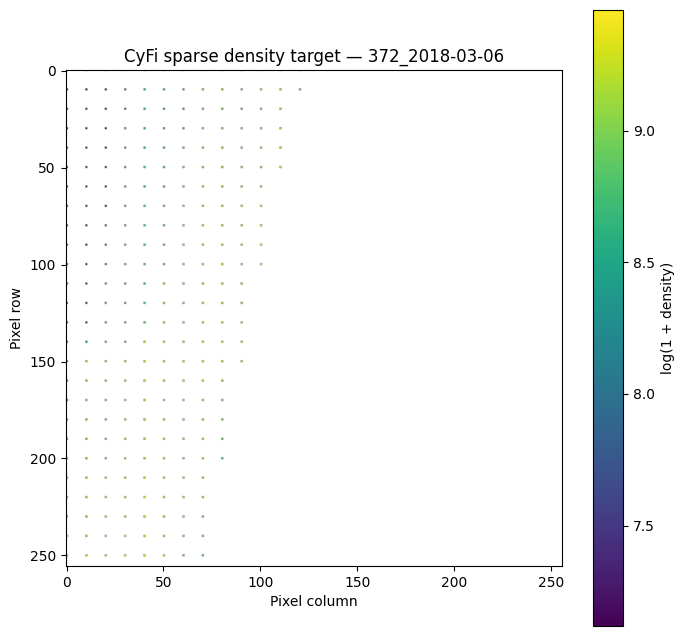

In [96]:
# ============================================
# STEP 58: Visualize sparse density target
# ============================================

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))

masked_target = np.ma.masked_where(
    density_mask == 0,
    density_log_target
)

plt.imshow(masked_target)

plt.colorbar(
    label="log(1 + density)"
)

plt.title(
    f"CyFi sparse density target — {test_uid}"
)

plt.xlabel("Pixel column")
plt.ylabel("Pixel row")

plt.show()

In [97]:
# ============================================
# STEP 59: SCL distribution in crop
# ============================================

unique_scl, scl_counts = np.unique(
    scl_256,
    return_counts=True
)

scl_distribution = pd.DataFrame({
    "SCL_class": unique_scl,
    "pixel_count": scl_counts,
    "percentage": (
        scl_counts / scl_counts.sum() * 100
    )
})

display(scl_distribution)

,SCL_class,pixel_count,percentage
0,2,914,1.394653
1,4,6387,9.745789
2,5,33047,50.425720
3,6,24586,37.515259
4,7,472,0.720215
5,8,118,0.180054
6,9,4,0.006104
7,11,8,0.012207


In [98]:
# ============================================
# STEP 60: SCL at CyFi supervision points
# ============================================

cyfi_crop["scl_value"] = [
    scl_256[
        int(r),
        int(c)
    ]
    for r, c in zip(
        cyfi_crop["crop_pixel_row"],
        cyfi_crop["crop_pixel_col"]
    )
]

print(
    cyfi_crop["scl_value"].value_counts()
)

display(
    cyfi_crop[
        [
            "crop_pixel_row",
            "crop_pixel_col",
            "density_cells_per_ml",
            "severity",
            "scl_value"
        ]
    ].head(20)
)

scl_value
6    264
Name: count, dtype: int64


,crop_pixel_row,crop_pixel_col,density_cells_per_ml,severity,scl_value
0,0,0,1253.0,low,6
1,0,10,1366.0,low,6
2,0,20,1555.0,low,6
3,0,30,3886.0,low,6
4,0,40,6026.0,low,6
5,0,50,6026.0,low,6
6,0,60,6026.0,low,6
7,0,70,8620.0,low,6
8,0,80,8620.0,low,6
9,0,90,8620.0,low,6


In [99]:
# ============================================
# STEP 61: Spectral statistics
# ============================================

band_stats = []

for i, band in enumerate(BANDS):

    arr = image_256[:, :, i]

    band_stats.append({
        "band": band,
        "dtype": arr.dtype,
        "min": float(np.nanmin(arr)),
        "p01": float(np.nanpercentile(arr, 1)),
        "median": float(np.nanpercentile(arr, 50)),
        "p99": float(np.nanpercentile(arr, 99)),
        "max": float(np.nanmax(arr)),
        "zero_fraction": float(
            np.mean(arr == 0)
        )
    })

band_stats_df = pd.DataFrame(
    band_stats
)

display(band_stats_df)

,band,dtype,min,p01,median,p99,max,zero_fraction
0,B02,uint16,74.0,151.00,337.0,1688.00,4516.0,0.0
1,B03,uint16,118.0,151.00,490.5,2226.00,4600.0,0.0
2,B04,uint16,30.0,51.00,480.0,2547.30,3970.0,0.0
3,B05,uint16,23.0,42.00,671.0,2649.00,3446.0,0.0
4,B06,uint16,1.0,8.00,717.0,4674.30,5256.0,0.0
5,B07,uint16,1.0,10.35,785.0,6022.00,6782.0,0.0
6,B08,uint16,1.0,3.00,853.0,6424.00,7280.0,0.0
7,B8A,uint16,1.0,11.00,894.0,6102.00,6917.0,0.0
8,B11,uint16,27.0,42.00,1767.0,4222.00,4510.0,0.0
9,B12,uint16,27.0,45.00,1477.0,3914.65,4141.0,0.0


In [100]:
# ============================================
# STEP 62: Download metadata
# ============================================

metadata_path = hf_hub_download(
    repo_id=REPO_ID,
    filename=f"data/{test_uid}/metadata.json",
    revision=REVISION,
    repo_type="dataset"
)

print("Metadata:", metadata_path)

metadata.json:   0%|          | 0.00/661 [00:00<?, ?B/s]

Metadata: /root/.cache/huggingface/hub/datasets--kostaspic--amfitrite-inland-waters-hab-sentinel2/snapshots/88dda2242db358dc2464ef14a00e548acbd8d558/data/372_2018-03-06/metadata.json


In [101]:
# ============================================
# STEP 62B: Inspect metadata
# ============================================

import json

with open(metadata_path, "r") as f:
    metadata = json.load(f)

print(json.dumps(metadata, indent=2))

{
  "item_id": "S2A_MSIL2A_20180306T185231_R113_T10SFF_20201013T071652",
  "per_clouds": 0.73,
  "water_pixels": 31137,
  "uid": "nhdx",
  "abun": 6065.0,
  "tile_size_10m_pixels": 365,
  "date": "2018-03-06",
  "center_lat": 36.7723,
  "center_lon": -121.788,
  "points_data": [
    {
      "uid": "nhdx",
      "lat": 36.7723,
      "lon": -121.788,
      "date": "2018-03-01",
      "abun": 6065.0,
      "severity": 4
    }
  ],
  "High counts": 1,
  "Moderate counts ": 12,
  "Low counts ": 323,
  "compatibility_analysis": {
    "clusters": []
  }
}


In [102]:
# ============================================
# STEP 63: Inspect raster geospatial metadata
# ============================================

for band in ["B02", "B08", "B11", "SCL"]:

    with rasterio.open(
        downloaded_paths[band]
    ) as src:

        print("\n" + "=" * 60)
        print(band)

        print("CRS:", src.crs)
        print("Width:", src.width)
        print("Height:", src.height)
        print("Resolution:", src.res)
        print("Bounds:", src.bounds)
        print("Transform:")
        print(src.transform)


B02
CRS: EPSG:32610
Width: 365
Height: 365
Resolution: (10.0, 10.0)
Bounds: BoundingBox(left=606330.0, bottom=4068480.0, right=609980.0, top=4072130.0)
Transform:
| 10.00, 0.00, 606330.00|
| 0.00,-10.00, 4072130.00|
| 0.00, 0.00, 1.00|

B08
CRS: EPSG:32610
Width: 365
Height: 365
Resolution: (10.0, 10.0)
Bounds: BoundingBox(left=606330.0, bottom=4068480.0, right=609980.0, top=4072130.0)
Transform:
| 10.00, 0.00, 606330.00|
| 0.00,-10.00, 4072130.00|
| 0.00, 0.00, 1.00|

B11
CRS: EPSG:32610
Width: 365
Height: 365
Resolution: (10.0, 10.0)
Bounds: BoundingBox(left=606330.0, bottom=4068480.0, right=609980.0, top=4072130.0)
Transform:
| 10.00, 0.00, 606330.00|
| 0.00,-10.00, 4072130.00|
| 0.00, 0.00, 1.00|

SCL
CRS: EPSG:32610
Width: 365
Height: 365
Resolution: (10.0, 10.0)
Bounds: BoundingBox(left=606330.0, bottom=4068480.0, right=609980.0, top=4072130.0)
Transform:
| 10.00, 0.00, 606330.00|
| 0.00,-10.00, 4072130.00|
| 0.00, 0.00, 1.00|


In [103]:
# ============================================
# STEP 64: Verify band alignment
# ============================================

reference_band = "B02"

with rasterio.open(
    downloaded_paths[reference_band]
) as ref:

    reference_shape = (
        ref.height,
        ref.width
    )

    reference_transform = ref.transform
    reference_crs = ref.crs
    reference_res = ref.res


alignment_results = []

for band in BANDS:

    with rasterio.open(
        downloaded_paths[band]
    ) as src:

        alignment_results.append({
            "band": band,
            "shape": (
                src.height,
                src.width
            ),
            "same_shape": (
                src.height,
                src.width
            ) == reference_shape,
            "same_transform": (
                src.transform == reference_transform
            ),
            "same_crs": (
                src.crs == reference_crs
            ),
            "same_resolution": (
                src.res == reference_res
            )
        })

alignment_df = pd.DataFrame(
    alignment_results
)

display(alignment_df)

,band,shape,same_shape,same_transform,same_crs,same_resolution
0,B02,"(365, 365)",True,True,True,True
1,B03,"(365, 365)",True,True,True,True
2,B04,"(365, 365)",True,True,True,True
3,B05,"(365, 365)",True,True,True,True
4,B06,"(365, 365)",True,True,True,True
5,B07,"(365, 365)",True,True,True,True
6,B08,"(365, 365)",True,True,True,True
7,B8A,"(365, 365)",True,True,True,True
8,B11,"(365, 365)",True,True,True,True
9,B12,"(365, 365)",True,True,True,True


In [104]:
print(
    "All shapes aligned:",
    alignment_df["same_shape"].all()
)

print(
    "All transforms aligned:",
    alignment_df["same_transform"].all()
)

print(
    "All CRS aligned:",
    alignment_df["same_crs"].all()
)

print(
    "All resolutions aligned:",
    alignment_df["same_resolution"].all()
)

All shapes aligned: True
All transforms aligned: True
All CRS aligned: True
All resolutions aligned: True


In [105]:
# ============================================
# STEP 65: Select SCL validation cases
# ============================================

scl_validation_uids = []

for cls in ["High", "Moderate", "Low"]:

    candidates = master_manifest[
        (master_manifest["split"] == "train") &
        (master_manifest["abun_class"] == cls)
    ]

    scl_validation_uids.extend(
        candidates["uid"].head(2).tolist()
    )

# Two unmeasured cases
unmeasured_candidates = master_manifest[
    (master_manifest["split"] == "train") &
    (master_manifest["abun_n"] == 0)
]

scl_validation_uids.extend(
    unmeasured_candidates["uid"].head(2).tolist()
)

print("Cases selected:", len(scl_validation_uids))
print(scl_validation_uids)

Cases selected: 8
['372_2018-03-06', '403_2018-01-24', '164_2021-05-27', '1414_2017-07-31', '95_2019-04-15', '510_2021-04-30', '78_2020-04-21', '2209_2018-05-13']


In [106]:
# ============================================
# STEP 66: Download SCL + CyFi validation files
# ============================================

scl_cyfi_paths = {}

for uid in scl_validation_uids:

    scl_path = hf_hub_download(
        repo_id=REPO_ID,
        filename=f"data/{uid}/SCL_raw.tif",
        revision=REVISION,
        repo_type="dataset"
    )

    cyfi_path = hf_hub_download(
        repo_id=REPO_ID,
        filename=f"data/{uid}/cyfi_lattice_predictions.csv",
        revision=REVISION,
        repo_type="dataset"
    )

    scl_cyfi_paths[uid] = {
        "scl": scl_path,
        "cyfi": cyfi_path
    }

print(
    "Downloaded validation cases:",
    len(scl_cyfi_paths)
)

data/403_2018-01-24/SCL_raw.tif: reconstructing file:   0%|          |  0.00B /  134kB            

data/403_2018-01-24/SCL_raw.tif: downloading bytes:           |  0.00B            

cyfi_lattice_predictions.csv:   0%|          | 0.00/6.71k [00:00<?, ?B/s]

data/164_2021-05-27/SCL_raw.tif: reconstructing file:   0%|          |  0.00B /  134kB            

data/164_2021-05-27/SCL_raw.tif: downloading bytes:           |  0.00B            

...

data/78_2020-04-21/SCL_raw.tif: downloading bytes:           |  0.00B            

data/2209_2018-05-13/SCL_raw.tif: reconstructing file:   0%|          |  0.00B /  134kB            

data/2209_2018-05-13/SCL_raw.tif: downloading bytes:           |  0.00B            

cyfi_lattice_predictions.csv:   0%|          | 0.00/56.9k [00:00<?, ?B/s]

Downloaded validation cases: 8


In [107]:
# ============================================
# STEP 67: SCL classes at CyFi points
# ============================================

scl_point_records = []

for uid in scl_validation_uids:

    row = master_manifest[
        master_manifest["uid"] == uid
    ].iloc[0]

    crop_row = int(row["crop_row"])
    crop_col = int(row["crop_col"])

    with rasterio.open(
        scl_cyfi_paths[uid]["scl"]
    ) as src:

        scl = src.read(1)

    cyfi = pd.read_csv(
        scl_cyfi_paths[uid]["cyfi"]
    )

    # Transform original 365x365 coordinates
    cyfi["crop_pixel_row"] = (
        cyfi["pixel_row"] - crop_row
    )

    cyfi["crop_pixel_col"] = (
        cyfi["pixel_col"] - crop_col
    )

    # Keep only points inside 256x256 crop
    inside = (
        (cyfi["crop_pixel_row"] >= 0) &
        (cyfi["crop_pixel_row"] < 256) &
        (cyfi["crop_pixel_col"] >= 0) &
        (cyfi["crop_pixel_col"] < 256)
    )

    cyfi = cyfi.loc[inside].copy()

    if len(cyfi) == 0:
        continue

    cyfi["scl_value"] = [
        scl[
            int(r),
            int(c)
        ]
        for r, c in zip(
            cyfi["crop_pixel_row"],
            cyfi["crop_pixel_col"]
        )
    ]

    for value in cyfi["scl_value"]:
        scl_point_records.append({
            "uid": uid,
            "scl_value": int(value)
        })

scl_point_df = pd.DataFrame(
    scl_point_records
)

display(
    pd.crosstab(
        scl_point_df["uid"],
        scl_point_df["scl_value"]
    )
)

scl_value,2,4,5,6,7
uid,,,,,
1414_2017-07-31,2,7,10,103,2
164_2021-05-27,6,40,2,192,4
2209_2018-05-13,18,36,114,419,3
372_2018-03-06,0,0,0,264,0
403_2018-01-24,2,39,48,8,2
510_2021-04-30,0,0,0,625,0
78_2020-04-21,0,0,0,84,0
95_2019-04-15,0,0,0,676,0


In [108]:
print(
    "Overall SCL distribution at CyFi points:"
)

print(
    scl_point_df["scl_value"]
    .value_counts()
    .sort_index()
)

Overall SCL distribution at CyFi points:
scl_value
2      28
4     122
5     174
6    2371
7      11
Name: count, dtype: int64


In [109]:
# ============================================
# STEP 68: SCL distribution for test crop
# ============================================

unique_scl, counts = np.unique(
    scl_256,
    return_counts=True
)

scl_df = pd.DataFrame({
    "SCL": unique_scl,
    "pixels": counts,
    "percentage": (
        counts / counts.sum() * 100
    )
})

display(scl_df)

,SCL,pixels,percentage
0,2,914,1.394653
1,4,6387,9.745789
2,5,33047,50.425720
3,6,24586,37.515259
4,7,472,0.720215
5,8,118,0.180054
6,9,4,0.006104
7,11,8,0.012207


In [110]:
# ============================================
# STEP 69: Compare SCL water count
# ============================================

scl_water_pixels = int(
    np.sum(scl_256 == 6)
)

summary_water_pixels = int(
    test_row["new_water_pixels"]
)

print(
    "SCL-derived water pixels:",
    scl_water_pixels
)

print(
    "Summary new_water_pixels:",
    summary_water_pixels
)

print(
    "Difference:",
    scl_water_pixels - summary_water_pixels
)

SCL-derived water pixels: 24586
Summary new_water_pixels: 24586
Difference: 0


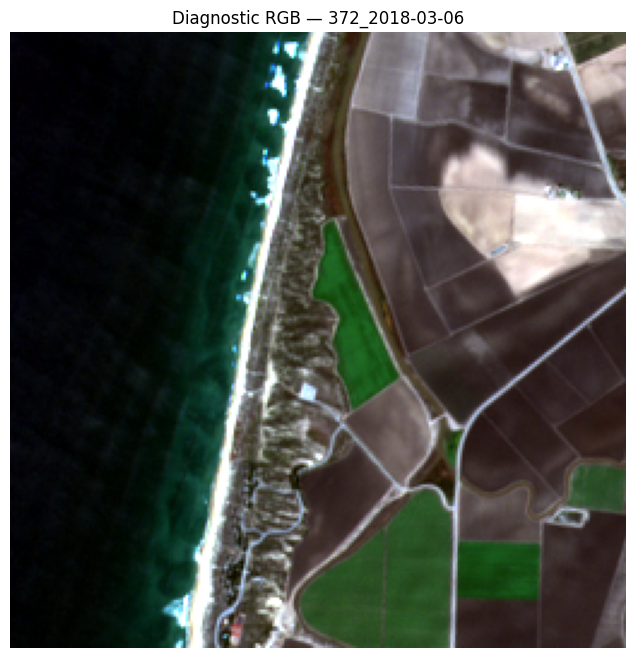

In [111]:
# ============================================
# STEP 70: Diagnostic RGB visualization
# ============================================

rgb = image_256[:, :, [2, 1, 0]].astype(
    np.float32
)

# Percentile stretch for visualization only
rgb_min = np.percentile(
    rgb,
    2,
    axis=(0, 1),
    keepdims=True
)

rgb_max = np.percentile(
    rgb,
    98,
    axis=(0, 1),
    keepdims=True
)

rgb_display = (
    rgb - rgb_min
) / (
    rgb_max - rgb_min + 1e-6
)

rgb_display = np.clip(
    rgb_display,
    0,
    1
)

plt.figure(figsize=(8, 8))

plt.imshow(rgb_display)

plt.title(
    f"Diagnostic RGB — {test_uid}"
)

plt.axis("off")

plt.show()

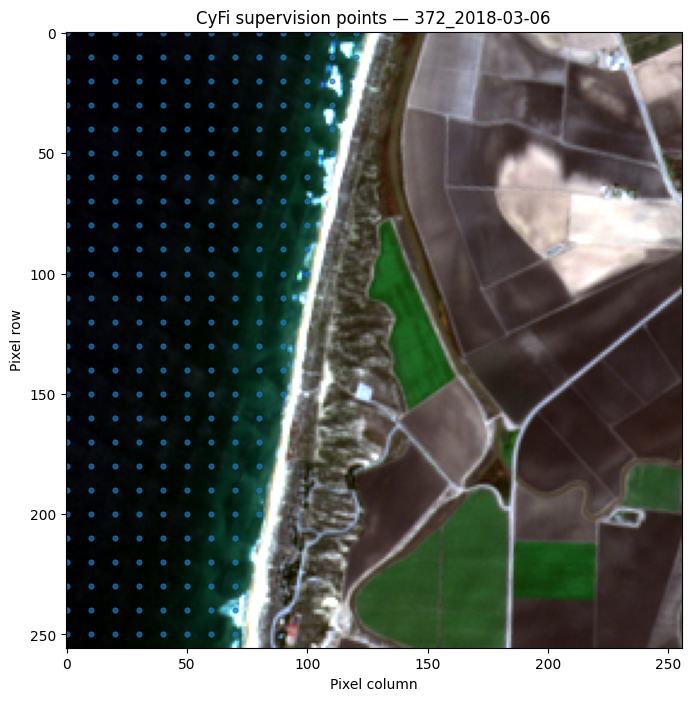

In [112]:
# ============================================
# STEP 71: Overlay CyFi points
# ============================================

plt.figure(figsize=(8, 8))

plt.imshow(rgb_display)

plt.scatter(
    cyfi_crop["crop_pixel_col"],
    cyfi_crop["crop_pixel_row"],
    s=12,
    alpha=0.7
)

plt.title(
    f"CyFi supervision points — {test_uid}"
)

plt.xlabel("Pixel column")
plt.ylabel("Pixel row")

plt.show()

In [113]:
def build_spatial_target(
    cyfi_df,
    crop_row,
    crop_col,
    height=256,
    width=256
):
    """
    Convert CyFi lattice predictions from
    original 365x365 coordinates into a
    sparse 256x256 target.
    """

    cyfi = cyfi_df.copy()

    # Convert coordinates to crop coordinates
    cyfi["r"] = (
        cyfi["pixel_row"] - crop_row
    )

    cyfi["c"] = (
        cyfi["pixel_col"] - crop_col
    )

    # Keep only points inside crop
    valid = (
        (cyfi["r"] >= 0) &
        (cyfi["r"] < height) &
        (cyfi["c"] >= 0) &
        (cyfi["c"] < width)
    )

    cyfi = cyfi.loc[valid].copy()

    density_target = np.zeros(
        (height, width),
        dtype=np.float32
    )

    density_mask = np.zeros(
        (height, width),
        dtype=np.float32
    )

    for _, row in cyfi.iterrows():

        r = int(row["r"])
        c = int(row["c"])

        density_target[r, c] = float(
            row["density_cells_per_ml"]
        )

        density_mask[r, c] = 1.0

    return (
        density_target,
        density_mask,
        cyfi
    )

In [114]:
# ============================================
# STEP 72: Create AlgaTrace project structure
# ============================================

from pathlib import Path

PROJECT_ROOT = Path("AlgaTrace")

PROJECT_DIRS = [
    PROJECT_ROOT / "data" / "manifests",
    PROJECT_ROOT / "data" / "samples" / "temporary_test_cases",
    PROJECT_ROOT / "data" / "tfrecords",
    PROJECT_ROOT / "models",
    PROJECT_ROOT / "results",
    PROJECT_ROOT / "inference",
]

for directory in PROJECT_DIRS:
    directory.mkdir(
        parents=True,
        exist_ok=True
    )

print("AlgaTrace project structure created.")

AlgaTrace project structure created.


In [115]:
# ============================================
# STEP 72B: Save the master manifest
# ============================================

MANIFEST_PATH = (
    PROJECT_ROOT
    / "data"
    / "manifests"
    / "alga_trace_master_manifest.csv"
)

master_manifest.to_csv(
    MANIFEST_PATH,
    index=False
)

print("Manifest saved to:")
print(MANIFEST_PATH)

Manifest saved to:
AlgaTrace/data/manifests/alga_trace_master_manifest.csv


In [116]:
# ============================================
# STEP 73: Water mask
# ============================================

WATER_SCL_VALUE = 6

def build_water_mask(scl_256):
    """
    Build a binary water mask from Sentinel-2 SCL.

    1 = water
    0 = non-water / invalid
    """

    return (
        scl_256 == WATER_SCL_VALUE
    ).astype(np.float32)

In [117]:
# ============================================
# STEP 73: Water mask
# ============================================

WATER_SCL_VALUE = 6

def build_water_mask(scl_256):
    """
    Build a binary water mask from Sentinel-2 SCL.

    1 = water
    0 = non-water / invalid
    """

    return (
        scl_256 == WATER_SCL_VALUE
    ).astype(np.float32)

In [118]:
water_mask = build_water_mask(scl_256)

print("Water pixels:", int(water_mask.sum()))
print("Total pixels:", water_mask.size)
print(
    "Water percentage:",
    water_mask.mean() * 100
)

Water pixels: 24586
Total pixels: 65536
Water percentage: 37.51526


In [119]:
# ============================================
# STEP 74: Build valid CyFi supervision
# ============================================

def build_spatial_target(
    cyfi_df,
    crop_row,
    crop_col,
    scl_256,
    height=256,
    width=256
):
    """
    Convert CyFi predictions from 365x365
    coordinates into a sparse 256x256 target.

    Only CyFi points located on SCL water pixels
    are used as density supervision.
    """

    cyfi = cyfi_df.copy()

    # ----------------------------------------
    # 1. Transform coordinates
    # ----------------------------------------

    cyfi["r"] = (
        cyfi["pixel_row"] - crop_row
    )

    cyfi["c"] = (
        cyfi["pixel_col"] - crop_col
    )

    # ----------------------------------------
    # 2. Keep points inside crop
    # ----------------------------------------

    valid_geometry = (
        (cyfi["r"] >= 0) &
        (cyfi["r"] < height) &
        (cyfi["c"] >= 0) &
        (cyfi["c"] < width)
    )

    cyfi = cyfi.loc[
        valid_geometry
    ].copy()

    # ----------------------------------------
    # 3. Keep valid density values
    # ----------------------------------------

    cyfi["density_cells_per_ml"] = pd.to_numeric(
        cyfi["density_cells_per_ml"],
        errors="coerce"
    )

    cyfi = cyfi[
        cyfi["density_cells_per_ml"].notna()
    ].copy()

    # ----------------------------------------
    # 4. Check SCL at every CyFi point
    # ----------------------------------------

    cyfi["scl_value"] = [
        scl_256[
            int(r),
            int(c)
        ]
        for r, c in zip(
            cyfi["r"],
            cyfi["c"]
        )
    ]

    # ----------------------------------------
    # 5. Keep only water points
    # ----------------------------------------

    cyfi = cyfi[
        cyfi["scl_value"] == WATER_SCL_VALUE
    ].copy()

    # ----------------------------------------
    # 6. Create sparse target
    # ----------------------------------------

    density_target = np.zeros(
        (height, width),
        dtype=np.float32
    )

    density_mask = np.zeros(
        (height, width),
        dtype=np.float32
    )

    for _, row in cyfi.iterrows():

        r = int(row["r"])
        c = int(row["c"])

        density_target[r, c] = (
            float(
                row["density_cells_per_ml"]
            )
        )

        density_mask[r, c] = 1.0

    return (
        density_target,
        density_mask,
        cyfi
    )

In [120]:
# ============================================
# STEP 75: Test target-generation function
# ============================================

cyfi_test = pd.read_csv(
    cyfi_local_paths["High"]
)

density_target, density_mask, cyfi_valid = (
    build_spatial_target(
        cyfi_df=cyfi_test,
        crop_row=crop_row,
        crop_col=crop_col,
        scl_256=scl_256
    )
)

print(
    "Valid CyFi supervision points:",
    int(density_mask.sum())
)

print(
    "Target shape:",
    density_target.shape
)

print(
    "Minimum density:",
    density_target[
        density_mask == 1
    ].min()
)

print(
    "Maximum density:",
    density_target[
        density_mask == 1
    ].max()
)

Valid CyFi supervision points: 72
Target shape: (256, 256)
Minimum density: 3175.0
Maximum density: 90073.0


In [121]:
# ============================================
# STEP 76: Log-density target
# ============================================

def log_transform_density(
    density_target,
    density_mask
):
    """
    Apply log1p only to supervised density pixels.
    """

    target_log = np.zeros_like(
        density_target,
        dtype=np.float32
    )

    valid = density_mask == 1

    target_log[valid] = np.log1p(
        density_target[valid]
    )

    return target_log

In [122]:
density_log_target = log_transform_density(
    density_target,
    density_mask
)

valid_values = (
    density_log_target[
        density_mask == 1
    ]
)

print(
    "Log-density range:",
    valid_values.min(),
    "→",
    valid_values.max()
)

Log-density range: 8.063377 → 11.408387


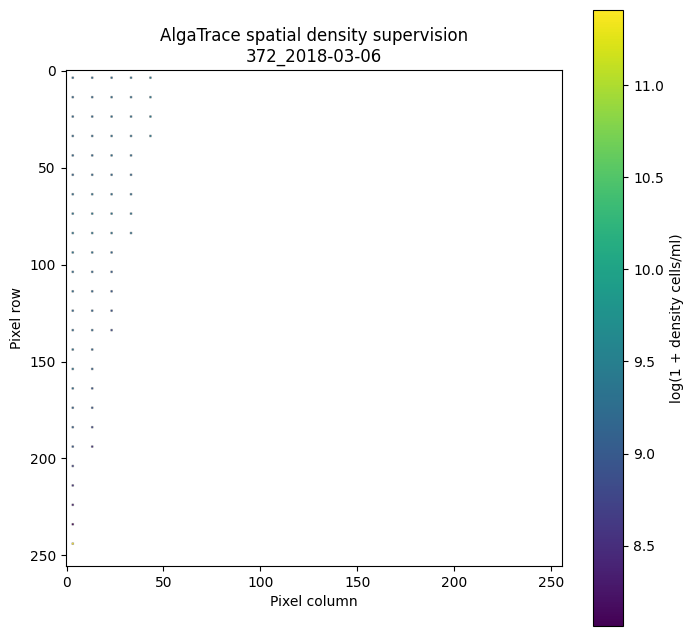

In [124]:
# ============================================
# STEP 77: Final target visualization
# ============================================

plt.figure(figsize=(8, 8))

target_display = np.ma.masked_where(
    density_mask == 0,
    density_log_target
)

plt.imshow(
    target_display
)

plt.colorbar(
    label="log(1 + density cells/ml)"
)

plt.title(
    f"AlgaTrace spatial density supervision\n{test_uid}"
)

plt.xlabel("Pixel column")
plt.ylabel("Pixel row")

plt.show()

In [125]:
# ============================================
# STEP 78: Validate target generation
# across all representative cases
# ============================================

target_validation_results = []

for uid in scl_validation_uids:

    row = master_manifest[
        master_manifest["uid"] == uid
    ].iloc[0]

    crop_row_i = int(row["crop_row"])
    crop_col_i = int(row["crop_col"])

    with rasterio.open(
        scl_cyfi_paths[uid]["scl"]
    ) as src:

        scl_i = src.read(1)

    cyfi_i = pd.read_csv(
        scl_cyfi_paths[uid]["cyfi"]
    )

    target_i, mask_i, valid_cyfi_i = (
        build_spatial_target(
            cyfi_df=cyfi_i,
            crop_row=crop_row_i,
            crop_col=crop_col_i,
            scl_256=scl_i[
                crop_row_i:crop_row_i + 256,
                crop_col_i:crop_col_i + 256
            ]
        )
    )

    target_validation_results.append({
        "uid": uid,
        "split": row["split"],
        "indicative_class": row[
            "new_indicative_class"
        ],
        "original_cyfi_points": len(cyfi_i),
        "valid_water_cyfi_points": int(
            mask_i.sum()
        ),
        "target_min": (
            target_i[mask_i == 1].min()
            if mask_i.sum() > 0
            else np.nan
        ),
        "target_max": (
            target_i[mask_i == 1].max()
            if mask_i.sum() > 0
            else np.nan
        )
    })

target_validation_df = pd.DataFrame(
    target_validation_results
)

display(
    target_validation_df
)

,uid,split,indicative_class,original_cyfi_points,valid_water_cyfi_points,target_min,target_max
0,372_2018-03-06,train,Low,336,264,1234.0,12811.0
1,403_2018-01-24,train,Low,99,99,2665.0,27555.0
2,164_2021-05-27,train,Moderate,354,244,3859.0,31243.0
3,1414_2017-07-31,train,Low,159,124,3029.0,22395.0
4,95_2019-04-15,train,Moderate,1369,676,14217.0,21755.0
5,510_2021-04-30,train,Moderate,1233,625,6777.0,28289.0
6,78_2020-04-21,train,Low,101,84,3661.0,8313.0
7,2209_2018-05-13,train,Low,841,590,866.0,16497.0


In [126]:
# ============================================
# STEP 81: Inspect TIFF radiometric metadata
# ============================================

for band in ["B02", "B04", "B08", "B11"]:

    with rasterio.open(
        downloaded_paths[band]
    ) as src:

        print("\n" + "=" * 60)
        print(band)

        print("Tags:")
        print(src.tags())

        print("\nBand tags:")
        print(src.tags(1))

        print("\nScales:")
        print(src.scales)

        print("\nOffsets:")
        print(src.offsets)


B02
Tags:
{'AREA_OR_POINT': 'Area'}

Band tags:
{}

Scales:
(1.0,)

Offsets:
(0.0,)

B04
Tags:
{'AREA_OR_POINT': 'Area'}

Band tags:
{}

Scales:
(1.0,)

Offsets:
(0.0,)

B08
Tags:
{'AREA_OR_POINT': 'Area'}

Band tags:
{}

Scales:
(1.0,)

Offsets:
(0.0,)

B11
Tags:
{'AREA_OR_POINT': 'Area'}

Band tags:
{}

Scales:
(1.0,)

Offsets:
(0.0,)


In [130]:
from pathlib import Path
import json
import pandas as pd

PROJECT_ROOT = Path("/content/AlgaTrace")

checkpoint = {
    "project": "AlgaTrace",
    "current_notebook": "02_build_training_dataset.ipynb",
    "status": "Paused after Sentinel-2 TIFF radiometric metadata audit",

    "dataset_id": "kostaspic/amfitrite-inland-waters-hab-sentinel2",
    "dataset_revision": "88dda2242db358dc2464ef14a00e548acbd8d558",

    "summary_rows": 4684,
    "repository_cases": 4698,
    "geographic_cases": 952,

    "split": {
        "method": "geographic_case_split",
        "random_seed": 42,
        "train_cases": 666,
        "validation_cases": 143,
        "test_cases": 143,
        "train_observations": 3391,
        "validation_observations": 650,
        "test_observations": 643
    },

    "bands": [
        "B02", "B03", "B04", "B05",
        "B06", "B07", "B08", "B8A",
        "B11", "B12"
    ],

    "water_mask": {
        "source": "Sentinel-2 SCL",
        "water_class": 6
    },

    "targets": {
        "spatial_target": "CyFi density_cells_per_ml",
        "target_transform": "log1p",
        "supervision": "sparse",
        "cyfi_severity_primary_target": False
    },

    "radiometry": {
        "tiff_scale_metadata": 1.0,
        "tiff_offset_metadata": 0.0,
        "status": "Need final confirmation before hard-coding preprocessing"
    },

    "next_step": "Verify Sentinel-2 L2A radiometry, then validate sparse CyFi target geometry"
}

checkpoint_dir = PROJECT_ROOT / "data" / "manifests"
checkpoint_dir.mkdir(parents=True, exist_ok=True)

checkpoint_path = checkpoint_dir / "project_checkpoint.json"

with open(checkpoint_path, "w") as f:
    json.dump(checkpoint, f, indent=2)

print("Checkpoint saved:")
print(checkpoint_path)

Checkpoint saved:
/content/AlgaTrace/data/manifests/project_checkpoint.json


In [131]:
from pathlib import Path
import pandas as pd

manifest_path = Path(
    "/content/AlgaTrace/data/manifests/alga_trace_master_manifest.csv"
)

print("Exists:", manifest_path.exists())

if manifest_path.exists():
    manifest = pd.read_csv(manifest_path)

    print("Shape:", manifest.shape)
    print("Columns:", len(manifest.columns))
    print()
    print(manifest[["uid", "case", "date", "split"]].head())

Exists: True
Shape: (4684, 41)
Columns: 41

               uid  case        date  split
0  1176_2017-10-31  1176  2017-10-31   test
1    78_2020-04-21    78  2020-04-21  train
2  2209_2018-05-13  2209  2018-05-13  train
3   372_2018-03-06   372  2018-03-06  train
4    95_2019-04-15    95  2019-04-15  train


In [132]:
from pathlib import Path

PROJECT_ROOT = Path("/content/AlgaTrace")

folders = [
    "data/manifests",
    "data/samples/temporary_test_cases",
    "data/tfrecords",
    "models",
    "results",
    "inference"
]

for folder in folders:
    (PROJECT_ROOT / folder).mkdir(parents=True, exist_ok=True)

print("AlgaTrace structure:")
for path in sorted(PROJECT_ROOT.rglob("*")):
    if path.is_dir():
        print("📁", path.relative_to(PROJECT_ROOT))

AlgaTrace structure:
📁 data
📁 data/manifests
📁 data/samples
📁 data/samples/temporary_test_cases
📁 data/tfrecords
📁 inference
📁 models
📁 results


In [133]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [134]:
from pathlib import Path
import shutil

backup_root = Path(
    "/content/drive/MyDrive/AlgaTrace_backup"
)

backup_root.mkdir(parents=True, exist_ok=True)

print(backup_root)

/content/drive/MyDrive/AlgaTrace_backup


In [135]:
shutil.copy2(
    "/content/AlgaTrace/data/manifests/alga_trace_master_manifest.csv",
    backup_root / "alga_trace_master_manifest.csv"
)

PosixPath('/content/drive/MyDrive/AlgaTrace_backup/alga_trace_master_manifest.csv')

In [136]:
shutil.copy2(
    "/content/AlgaTrace/data/manifests/project_checkpoint.json",
    backup_root / "project_checkpoint.json"
)

print("Backup completed.")

Backup completed.
